# Cell-type classification from patch-seq electrophysiology

This notebook compares two ways of classifying neurons into their transcriptomic
**RNA family** from intracellular recordings of the DANDI:000008 (M1 patch-seq) dataset:

1. **Predefined electrophysiology features** classified with **KNN**, **Random Forest** and **SVM**.
2. **Wavelet Scattering Transform (WST)** representations of the raw voltage traces,
   classified with three convolutional networks: **ResNet18**, **VGG16** and **Inception V3**.

All six models are trained and evaluated on **one shared, stratified split** (identical
final test cells and identical cross-validation folds) so the comparison between the
hand-crafted features and the learned WST representation is fair.

**Pipeline order**
1. Download the dataset.
2. Filter cells that contain the required sweeps.
3. Compute the WST representation per cell.
4. Build the shared fair split (run once).
5. Classical models (KNN / Random Forest / SVM) on predefined features.
6. Deep-learning models (ResNet18 / VGG16 / Inception V3) on WST S1.
7. Compare all models on the same test set.
8. (Optional) Save results to Google Drive.

> Update the file paths at the top of each cell if your CSV files are stored elsewhere.

In [ ]:
# Install the libraries that are not preinstalled on Colab.
!pip install -q dandi kymatio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.6/395.6 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.6/118.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2

In [ ]:
!mkdir -p /content/dandi_000008
!dandi download DANDI:000008/0.211014.0809 --output-dir /content/dandi_000008

PATH                                                                                                                      SIZE       DONE            DONE% CHECKSUM STATUS          MESSAGE   
000008/dandiset.yaml                                                                                                                                                done            updated   
000008/sub-mouse-AAYYT/sub-mouse-AAYYT_ses-20180420-sample-2_slice-20180420-slice-2_cell-20180420-sample-2_icephys.nwb    9.3 MB     9.3 MB           100%    ok    done                      
000008/sub-mouse-AAYYT/sub-mouse-AAYYT_ses-20180420-sample-3_slice-20180420-slice-3_cell-20180420-sample-3_icephys.nwb    9.3 MB     9.3 MB           100%    ok    done                      
000008/sub-mouse-AAYYT/sub-mouse-AAYYT_ses-20180420-sample-4_slice-20180420-slice-4_cell-20180420-sample-4_icephys.nwb    9.5 MB     9.5 MB           100%    ok    done                      
000008/sub-mouse-AEJGZ/sub-mouse-AEJGZ_ses-20

## Step 1 — Filter cells

Keep only cells that contain every required sweep (10–70) and whose sweeps are long
enough to be cropped to the analysis window. The list of accepted file paths is saved
as a `.npy` array for the next step.

In [ ]:
# ============================================================
# PREPROCESSING FILTER:
# Keep only cells that have *ALL* sweeps 10–70 inclusive,
# AND each sweep is long enough for CUT_END (so cropping works).
# Save the kept file paths as a .npy array (no CSV).
# ============================================================

import os, re, h5py
import numpy as np

ROOT_DIR    = "/content/dandi_000008"
SWEEP_START = 10
SWEEP_END   = 70
REQ_SWEEPS  = list(range(SWEEP_START, SWEEP_END + 1))

CUT_START   = 2500
CUT_END     = 17500  # must have len >= CUT_END

OUT_NPY     = f"/content/kept_cells_sweeps{SWEEP_START:03d}_{SWEEP_END:03d}_cut{CUT_START}_{CUT_END}.npy"

# ----------------------------
# Helpers
# ----------------------------
def find_nwb_files(root):
    out = []
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            if fn.endswith(".nwb"):
                out.append(os.path.join(dirpath, fn))
    return sorted(out)

def has_sweep_and_long_enough(f, sidx, cut_end):
    acq = f.get("acquisition", None)
    if acq is None:
        return False, "no_acquisition"
    key = f"CurrentClampSeries{sidx:03d}"
    if key not in acq:
        return False, "missing_sweep"
    vlen = int(acq[key]["data"].shape[0])
    if vlen < cut_end:
        return False, "too_short"
    return True, None

# ----------------------------
# Scan all NWB files
# ----------------------------
nwb_files = find_nwb_files(ROOT_DIR)
print("Found NWB files:", len(nwb_files))
print(f"Required sweeps: {SWEEP_START}–{SWEEP_END} (n={len(REQ_SWEEPS)})")
print(f"Crop window: [{CUT_START}:{CUT_END}] → need each sweep length ≥ {CUT_END}")

kept_paths = []
skip = {"no_acquisition": 0, "missing_sweep": 0, "too_short": 0, "h5_error": 0, "other": 0}

for fp in nwb_files:
    try:
        with h5py.File(fp, "r") as f:
            ok = True
            first_fail_reason = None
            for sidx in REQ_SWEEPS:
                good, reason = has_sweep_and_long_enough(f, sidx, CUT_END)
                if not good:
                    ok = False
                    first_fail_reason = reason
                    break

            if ok:
                kept_paths.append(fp)
            else:
                if first_fail_reason in skip:
                    skip[first_fail_reason] += 1
                else:
                    skip["other"] += 1
    except Exception:
        skip["h5_error"] += 1

# ----------------------------
# Save kept list as .npy
# ----------------------------
kept_paths = np.array(kept_paths)
np.save(OUT_NPY, kept_paths)

print("\n================ SUMMARY ================")
print("Total NWB files scanned:", len(nwb_files))
print("Cells kept (have ALL sweeps 10–70, long enough):", len(kept_paths))
print("\nSkip counts (first failure per file):")
for k, v in skip.items():
    print(f"  {k}: {v}")

print("\n✅ Saved kept file paths to:", OUT_NPY)


Found NWB files: 1328
Required sweeps: 10–70 (n=61)
Crop window: [2500:17500] → need each sweep length ≥ 17500

================ SUMMARY ================
Total NWB files scanned: 1328
Cells kept (have ALL sweeps 10–70, long enough): 1264

Skip counts (first failure per file):
  no_acquisition: 0
  missing_sweep: 64
  too_short: 0
  h5_error: 0
  other: 0

✅ Saved kept file paths to: /content/kept_cells_sweeps010_070_cut2500_17500.npy


## Step 2 — Wavelet Scattering Transform (WST)

For each accepted cell, crop sweeps 10–70 to `[CUT_START:CUT_END]`, stack them into one
fixed-length trace, z-score it, and compute the 1-D scattering transform
(`J=12`, `Q=20`, `max_order=2`). The S0/S1/S2 coefficients are saved as one `.npz` per
cell. The deep-learning models below use the **S1** coefficients as a 2-D image.

In [ ]:
# ============================================================
# STEP 2 (AFTER YOUR FILTER):
# Load kept_paths (.npy)  -> for each kept cell:
#   - crop sweeps 10..70 at [CUT_START:CUT_END]
#   - stack in sweep order => fixed length trace (61 * SEG_LEN)
#   - z-score per cell
#   - compute WST with J=12, Q=20, max_order=2
#   - save ONE NPZ PER CELL with proper identifiers for later joins
# Also:
#   - make WST+trace figures for 9 random cells
# ============================================================

import os, re, random
import numpy as np
import h5py
import matplotlib.pyplot as plt

import torch
from kymatio.torch import Scattering1D

# ----------------------------
# INPUT: the file you already created
# ----------------------------
KEPT_NPY = "/content/kept_cells_sweeps010_070_cut2500_17500.npy"

# ----------------------------
# CONFIG (must match filter)
# ----------------------------
SWEEP_START = 10
SWEEP_END   = 70
REQ_SWEEPS  = list(range(SWEEP_START, SWEEP_END + 1))

CUT_START = 2500
CUT_END   = 17500
SEG_LEN   = CUT_END - CUT_START

# WST params (as requested)
J = 12
Q = 20
OVERSAMPLING = 0
MAX_ORDER = 2

# Outputs
OUTDIR = f"/content/WST_kept_cells_sweeps{SWEEP_START:03d}_{SWEEP_END:03d}_cut{CUT_START}_{CUT_END}_J{J}_Q{Q}"
PER_CELL_DIR = os.path.join(OUTDIR, "per_cell_npz")
FIG_DIR      = os.path.join(OUTDIR, "figures_random9")

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(PER_CELL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# Random plots
N_RANDOM_PLOTS = 9
RANDOM_SEED = 42

# ----------------------------
# Helpers
# ----------------------------
def file_to_cell_id(fp: str) -> str:
    return os.path.splitext(os.path.basename(fp))[0]

def cell_id_to_short_id(cell_id: str):
    m = re.search(r"ses-(\d+)-sample-(\d+)", str(cell_id))
    return f"{m.group(1)}_sample_{m.group(2)}" if m else None

def safe_name(x: str) -> str:
    return re.sub(r"[^\w\-_\.]+", "_", str(x))

def zscore_1d(x, eps=1e-8):
    x = x.astype(np.float32)
    return (x - x.mean()) / (x.std() + eps)

def save_fig(path, dpi=220):
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close()

def plot_one_cell_bundle(out_subdir, name, stacked, seg_len,
                         S0, S1, S2, xi1_sorted, xi_pairs_sorted, parent_change_rows):
    os.makedirs(out_subdir, exist_ok=True)

    # stacked trace + boundaries
    plt.figure(figsize=(18, 4))
    plt.plot(stacked, lw=0.8)
    for k in range(1, (SWEEP_END - SWEEP_START + 1)):
        plt.axvline(k * seg_len, color="k", alpha=0.15, lw=1)
    plt.title(f"Stacked voltage | {name} | sweeps {SWEEP_START}-{SWEEP_END} | cut[{CUT_START}:{CUT_END}]")
    plt.xlabel("stacked index")
    plt.ylabel("voltage (raw units)")
    save_fig(os.path.join(out_subdir, "01_stacked_trace.png"))

    # S0
    plt.figure(figsize=(10, 2.6))
    plt.plot(S0, lw=1.2)
    plt.title("WST S0")
    plt.xlabel("WST time frames")
    plt.ylabel("S0")
    save_fig(os.path.join(out_subdir, "02_S0.png"))

    # S1 heatmap (y-axis = xi1)
    plt.figure(figsize=(11, 4.5))
    plt.imshow(S1, aspect="auto", origin="upper", cmap="jet")
    ax = plt.gca()
    K = len(xi1_sorted)
    step = max(1, K // 10)
    ticks = np.arange(0, K, step)
    ax.set_yticks(ticks)
    ax.set_yticklabels([f"{xi1_sorted[t]:.3f}" for t in ticks])
    plt.title("WST S1 (sorted by xi1 desc)")
    plt.xlabel("WST time frames")
    plt.ylabel("xi1")
    plt.colorbar()
    save_fig(os.path.join(out_subdir, "03_S1.png"))

    # S2 heatmap (normalize per-parent for visualization)
    S2n = S2.copy()
    start = 0
    for brk in list(parent_change_rows) + [S2n.shape[0]]:
        block = S2n[start:brk]
        d = np.max(block)
        if d > 0:
            S2n[start:brk] = block / d
        start = brk

    plt.figure(figsize=(12, 5.5))
    plt.imshow(S2n, aspect="auto", origin="upper", cmap="jet")
    ax = plt.gca()
    for r in parent_change_rows:
        ax.axhline(y=r - 0.5, color="white", linewidth=0.6, alpha=0.9)

    npaths = S2n.shape[0]
    step2 = max(1, npaths // 12)
    ticks2 = np.arange(0, npaths, step2)
    ax.set_yticks(ticks2)
    ax.set_yticklabels(
        [f"({xi_pairs_sorted[t,0]:.3f},{xi_pairs_sorted[t,1]:.3f})" for t in ticks2],
        fontsize=8
    )
    plt.title("WST S2 (sorted; per-parent normalized for visualization)")
    plt.xlabel("WST time frames")
    plt.ylabel("(xi1, xi2)")
    plt.colorbar()
    save_fig(os.path.join(out_subdir, "04_S2.png"))

# ----------------------------
# Load kept paths
# ----------------------------
kept_paths = np.load(KEPT_NPY, allow_pickle=True)
kept_paths = [str(p) for p in kept_paths]
N = len(kept_paths)
print("✅ Loaded kept cells:", N)

if N == 0:
    raise RuntimeError("kept_paths is empty. Check your filter output file.")

# Fixed stacked length since all sweeps exist for these cells
N_SWEEPS  = len(REQ_SWEEPS)
L_total   = N_SWEEPS * SEG_LEN
print("Sweeps used:", SWEEP_START, "to", SWEEP_END, "| count =", N_SWEEPS)
print("SEG_LEN:", SEG_LEN, "=> stacked length L_total:", L_total)

# ----------------------------
# Build WST object (fixed length!)
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

scattering = Scattering1D(
    J=J, shape=L_total, Q=Q,
    oversampling=OVERSAMPLING,
    max_order=MAX_ORDER
).to(device)

meta = scattering.meta()
order = meta["order"]
xi_all = meta["xi"]

order0 = np.where(order == 0)[0]
order1 = np.where(order == 1)[0]
order2 = np.where(order == 2)[0]

# sort S1 by xi1 desc
xi1 = xi_all[order1, 0]
sort1 = np.argsort(xi1)[::-1]
xi1_sorted = xi1[sort1].astype(np.float32)

# sort S2 by (xi1 desc, xi2 desc)
xi_pairs = xi_all[order2]
perm_S2 = np.lexsort((-xi_pairs[:, 1], -xi_pairs[:, 0]))
xi_pairs_sorted = xi_pairs[perm_S2].astype(np.float32)

parent_change_rows = (np.where(np.diff(xi_pairs_sorted[:, 0]) != 0)[0] + 1).astype(int)

# ----------------------------
# Main loop: crop sweeps, stack, WST, save NPZ
# ----------------------------
saved_npz_paths = []
bad_cells = 0

for i, fp in enumerate(kept_paths):
    cell_id = file_to_cell_id(fp)
    short_id = cell_id_to_short_id(cell_id)
    name = f"{cell_id}__sweeps{SWEEP_START:03d}_{SWEEP_END:03d}__cut{CUT_START}_{CUT_END}"

    try:
        segs = []
        with h5py.File(fp, "r") as f:
            acq = f["acquisition"]
            for sidx in REQ_SWEEPS:
                k = f"CurrentClampSeries{sidx:03d}"
                seg = acq[k]["data"][CUT_START:CUT_END].astype(np.float32)
                # should always be SEG_LEN due to filtering, but keep safe:
                if seg.shape[0] != SEG_LEN:
                    raise RuntimeError(f"Sweep {sidx:03d} seg_len {seg.shape[0]} != {SEG_LEN}")
                segs.append(seg)

        segs = np.stack(segs, axis=0)          # (61, SEG_LEN)
        stacked = segs.reshape(-1)             # (L_total,)
        x = zscore_1d(stacked)                 # z-score per cell

        x_torch = torch.from_numpy(x[None, None, :]).to(device)
        with torch.no_grad():
            Sx = scattering(x_torch).detach().cpu().numpy()

        if Sx.ndim == 4:
            Sx = Sx[:, 0]  # (1,C,T')
        if Sx.shape[1] != len(order):
            Sx = np.transpose(Sx, (0, 2, 1))

        S0 = Sx[:, order0, :]                  # (1,1,T')
        S1_uns = Sx[:, order1, :]
        S2_uns = Sx[:, order2, :]

        S1 = S1_uns[:, sort1, :].astype(np.float32)
        S2 = S2_uns[:, perm_S2, :].astype(np.float32)
        S0 = S0.astype(np.float32)

        out_npz = os.path.join(PER_CELL_DIR, f"{safe_name(name)}__WST.npz")
        np.savez_compressed(
            out_npz,
            name=np.array([name]),
            cell_id=np.array([cell_id]),
            short_id=np.array([short_id if short_id is not None else ""]),
            file_path=np.array([fp]),

            sweeps_used=np.array(REQ_SWEEPS, dtype=int),
            cut=np.array([CUT_START, CUT_END], dtype=int),
            seg_len=np.array([SEG_LEN], dtype=int),
            stacked_len=np.array([L_total], dtype=int),

            stacked_trace=stacked.astype(np.float32),  # raw stacked trace

            S0=S0[0],   # (1,T')
            S1=S1[0],   # (n1,T')
            S2=S2[0],   # (n2,T')

            xi1=xi1_sorted,
            xi_pairs=xi_pairs_sorted,
            parent_change_rows=parent_change_rows,

            # params
            J=np.array([J], dtype=int),
            Q=np.array([Q], dtype=int),
            oversampling=np.array([OVERSAMPLING], dtype=int),
            max_order=np.array([MAX_ORDER], dtype=int),
        )

        saved_npz_paths.append(out_npz)

    except Exception as e:
        bad_cells += 1
        if bad_cells <= 10:
            print("⚠️ Failed:", fp, "|", repr(e))
        continue

    if (i + 1) % 50 == 0 or (i + 1) == N:
        print(f"Processed {i+1}/{N} (saved {len(saved_npz_paths)} NPZ, failed {bad_cells})")

print("\n✅ Done WST for kept cells.")
print("Saved NPZ:", len(saved_npz_paths))
print("Failed:", bad_cells)
print("OUTDIR:", OUTDIR)
print("NPZ folder:", PER_CELL_DIR)

# ----------------------------
# Plot 9 random cells
# ----------------------------
if len(saved_npz_paths) > 0:
    random.seed(RANDOM_SEED)
    pick = random.sample(saved_npz_paths, k=min(N_RANDOM_PLOTS, len(saved_npz_paths)))

    for j, npz_path in enumerate(pick, 1):
        z = np.load(npz_path, allow_pickle=True)

        name = str(z["name"][0])
        stacked = z["stacked_trace"]
        S0 = z["S0"][0] if z["S0"].ndim == 2 else z["S0"]
        S1 = z["S1"]
        S2 = z["S2"]
        xi1_s = z["xi1"]
        xi_pairs_s = z["xi_pairs"]
        pcr = z["parent_change_rows"]

        out_subdir = os.path.join(FIG_DIR, f"{j:02d}__{safe_name(name)}")
        plot_one_cell_bundle(out_subdir, name, stacked, SEG_LEN,
                             S0, S1, S2, xi1_s, xi_pairs_s, pcr)

    print("\n✅ Saved random-9 figures to:", FIG_DIR)
else:
    print("\n⚠️ No NPZ files saved; skipping random-9 plots.")


✅ Loaded kept cells: 1264
Sweeps used: 10 to 70 | count = 61
SEG_LEN: 15000 => stacked length L_total: 915000
Device: cuda
Processed 50/1264 (saved 50 NPZ, failed 0)
Processed 100/1264 (saved 100 NPZ, failed 0)
Processed 150/1264 (saved 150 NPZ, failed 0)
Processed 200/1264 (saved 200 NPZ, failed 0)
Processed 250/1264 (saved 250 NPZ, failed 0)
Processed 300/1264 (saved 300 NPZ, failed 0)
Processed 350/1264 (saved 350 NPZ, failed 0)
Processed 400/1264 (saved 400 NPZ, failed 0)
Processed 450/1264 (saved 450 NPZ, failed 0)
Processed 500/1264 (saved 500 NPZ, failed 0)
Processed 550/1264 (saved 550 NPZ, failed 0)
Processed 600/1264 (saved 600 NPZ, failed 0)
Processed 650/1264 (saved 650 NPZ, failed 0)
Processed 700/1264 (saved 700 NPZ, failed 0)
Processed 750/1264 (saved 750 NPZ, failed 0)
Processed 800/1264 (saved 800 NPZ, failed 0)
Processed 850/1264 (saved 850 NPZ, failed 0)
Processed 900/1264 (saved 900 NPZ, failed 0)
Processed 950/1264 (saved 950 NPZ, failed 0)
Processed 1000/1264 (sav

## Step 3 — Build the shared fair split (run once)

This single cell defines train/test membership for **every** model. A cell is only kept
if it has both a WST `.npz` and a row in the predefined feature table, so no model is
scored on cells another model never saw. It writes `shared_cv_pool.csv`,
`shared_final_test_set.csv` and `shared_split_summary.json`. **Run it once before any
model cell** — the model cells only *load* this split, they never recreate it.

In [ ]:
# ============================================================
# BUILD THE SHARED FAIR SPLIT   (RUN THIS ONCE)
#
# Single source of truth for train / test membership. Every model
# (KNN, Random Forest, SVM, ResNet18, VGG16, Inception V3) loads exactly
# this split, so the comparison is fair:
#   - identical final TEST cells for every model
#   - identical 3-fold cross-validation membership (fold_id)
#
# A cell is eligible only if it has BOTH:
#   - a WST .npz file  (input for the deep-learning models), and
#   - a row in the predefined ephys feature table (input for KNN/RF/SVM)
# so no model is scored on cells another model never had access to.
# ============================================================

import os, re, glob, json, random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold

# ---- Paths (edit if your files live elsewhere) ----
META_PATH        = "/content/m1_patchseq_meta_data (1).csv"   # TAB-delimited
NPZ_DIR          = "/content/WST_kept_cells_sweeps010_070_cut2500_17500_J12_Q20/per_cell_npz"
FEATURE_CSV      = "/content/m1_patchseq_ephys_features.csv"
SHARED_SPLIT_DIR = "/content/shared_fair_splits"
os.makedirs(SHARED_SPLIT_DIR, exist_ok=True)

# ---- Split / filtering config (shared by ALL models) ----
SEED                  = 42
TEST_SIZE             = 0.20
K_FOLDS               = 3
MIN_SAMPLES_PER_CLASS = 20

random.seed(SEED)
np.random.seed(SEED)

# Merge the excitatory transcriptomic families into a single class.
MERGE_MAP = {
    "CT": "CT_ET_IT", "ET": "CT_ET_IT", "IT": "CT_ET_IT",
    "CTandET": "CT_ET_IT", "ITandET": "CT_ET_IT",
}

def merge_family_label(lbl):
    if lbl is None:
        return None
    return MERGE_MAP.get(str(lbl).strip(), str(lbl).strip())

def any_to_short_id(x):
    x = str(x)
    m = re.search(r"ses-(\d+)-sample-(\d+)", x)
    if m:
        return f"{m.group(1)}_sample_{m.group(2)}"
    m = re.search(r"(\d+)_sample_(\d+)", x)
    if m:
        return f"{m.group(1)}_sample_{m.group(2)}"
    return None

def npz_to_short_id(npz_path):
    try:
        z = np.load(npz_path, allow_pickle=True)
        if "short_id" in z:
            v = z["short_id"]
            if isinstance(v, np.ndarray):
                v = v.item() if v.size == 1 else v[0]
            sid = str(v).strip()
            if sid != "":
                return sid
    except Exception:
        pass
    return any_to_short_id(os.path.basename(npz_path))

# ---- 1) Labels from metadata ----
meta = pd.read_csv(META_PATH, sep="\t")
rna_cols = [c for c in meta.columns
            if c.strip().lower().replace(" ", "") == "rnafamily"]
if not rna_cols:
    raise ValueError("Could not find an 'RNA family' column in the metadata.")
rna_col = rna_cols[0]

meta["short_id"]   = meta["Cell"].astype(str).apply(any_to_short_id)
meta               = meta.dropna(subset=["short_id"]).copy()
meta["RNA_family"] = meta[rna_col].astype(str).str.strip().apply(merge_family_label)
meta               = meta[meta["RNA_family"].str.lower() != "low quality"].copy()
meta               = meta.drop_duplicates(subset=["short_id"]).reset_index(drop=True)
rna_map            = dict(zip(meta["short_id"], meta["RNA_family"]))

# ---- 2) Cells that have a WST npz ----
rows = []
for p in sorted(glob.glob(os.path.join(NPZ_DIR, "*.npz"))):
    sid = npz_to_short_id(p)
    fam = rna_map.get(sid)
    if sid is None or fam is None:
        continue
    rows.append({"short_id": sid, "RNA_family": fam})
df_npz = pd.DataFrame(rows).drop_duplicates(subset=["short_id"]).reset_index(drop=True)

# ---- 3) Cells that have predefined ephys features ----
feat = pd.read_csv(FEATURE_CSV)
best_feat_id_col = max(
    feat.columns,
    key=lambda c: feat[c].astype(str).apply(any_to_short_id).notna().sum()
)
feat["short_id"] = feat[best_feat_id_col].astype(str).apply(any_to_short_id)
feature_ids = set(feat.dropna(subset=["short_id"])["short_id"])

# ---- 4) Keep cells present in BOTH modalities ----
df_shared = df_npz[df_npz["short_id"].isin(feature_ids)].copy().reset_index(drop=True)

# ---- 5) Drop rare classes ----
counts       = df_shared["RNA_family"].value_counts()
keep_classes = counts[counts >= MIN_SAMPLES_PER_CLASS].index.tolist()
drop_classes = counts[counts <  MIN_SAMPLES_PER_CLASS].index.tolist()
df_shared    = df_shared[df_shared["RNA_family"].isin(keep_classes)].reset_index(drop=True)

print("Cells with WST npz + predefined features:",
      int(df_npz["short_id"].isin(feature_ids).sum()))
print("Shared cells after class filtering:", len(df_shared))
print(df_shared["RNA_family"].value_counts())
if drop_classes:
    print("Dropped rare classes (< %d cells):" % MIN_SAMPLES_PER_CLASS, drop_classes)

# ---- 6) One stratified final TEST set ----
shared_cv, shared_test = train_test_split(
    df_shared,
    test_size=TEST_SIZE,
    stratify=df_shared["RNA_family"],
    random_state=SEED,
)
shared_cv   = shared_cv.reset_index(drop=True)
shared_test = shared_test.reset_index(drop=True)

# ---- 7) One stratified K-fold split on the CV pool ----
shared_cv["fold_id"] = -1
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
for fold_id, (_, val_idx) in enumerate(
        skf.split(shared_cv, shared_cv["RNA_family"]), start=1):
    shared_cv.loc[val_idx, "fold_id"] = fold_id

# ---- 8) Save ----
shared_cv.to_csv(os.path.join(SHARED_SPLIT_DIR, "shared_cv_pool.csv"), index=False)
shared_test.to_csv(os.path.join(SHARED_SPLIT_DIR, "shared_final_test_set.csv"), index=False)

summary = {
    "seed": SEED,
    "test_size": TEST_SIZE,
    "k_folds": K_FOLDS,
    "min_samples_per_class": MIN_SAMPLES_PER_CLASS,
    "n_total_shared": int(len(df_shared)),
    "n_cv_pool": int(len(shared_cv)),
    "n_final_test": int(len(shared_test)),
    "classes": sorted(df_shared["RNA_family"].unique().tolist()),
    "cv_class_counts": shared_cv["RNA_family"].value_counts().to_dict(),
    "test_class_counts": shared_test["RNA_family"].value_counts().to_dict(),
}
with open(os.path.join(SHARED_SPLIT_DIR, "shared_split_summary.json"), "w") as f:
    json.dump(summary, f, indent=4)

print("\nShared fair split saved to:", SHARED_SPLIT_DIR)
print("CV pool:", len(shared_cv), "| Final test:", len(shared_test))
print("Classes:", summary["classes"])


Cells with WST npz + predefined features: 1172
Shared cells after class filtering: 1154
RNA_family
CT_ET_IT    358
Pvalb       286
Sst         270
Vip         152
Lamp5        88
Name: count, dtype: int64
Dropped rare classes (< 20 cells): ['Sncg', 'NP']

Shared fair split saved to: /content/shared_fair_splits
CV pool: 923 | Final test: 231
Classes: ['CT_ET_IT', 'Lamp5', 'Pvalb', 'Sst', 'Vip']


## Step 4 — Classical models on predefined ephys features

KNN, Random Forest and SVM are trained on the predefined electrophysiology features
using the shared 3-fold cross-validation, then evaluated on the shared final test set.
All three share the same imputation/scaling pipeline.

Shared split loaded
CV pool: 923
Final test: 231
Classes: ['CT_ET_IT', 'Lamp5', 'Pvalb', 'Sst', 'Vip']

Detected feature ID column: cell id

After merging shared split with features:
KNN/RF CV pool: 923
KNN/RF final test: 231

Exact shared split confirmed for KNN/RF.

Using all numeric predefined/ephys features.
Number of features used: 29
['AP Fano factor', 'AP amplitude (mV)', 'AP amplitude adaptation index', 'AP amplitude average adaptation index', 'AP coefficient of variation', 'AP threshold (mV)', 'AP width (ms)', 'Afterdepolarization (mV)', 'Afterhyperpolarization (mV)', 'Burstiness', 'ISI Fano factor', 'ISI adaptation index', 'ISI average adaptation index', 'ISI coefficient of variation', 'Input resistance (MOhm)', 'Latency (ms)', 'Latency @ +20pA current (ms)', 'Max number of APs', 'Membrane time constant (ms)', 'Rebound (mV)', 'Rebound number of APs', 'Resting membrane potential (mV)', 'Rheobase (pA)', 'Sag area (mV*s)', 'Sag ratio', 'Sag time (s)', 'Spike frequency adaptation

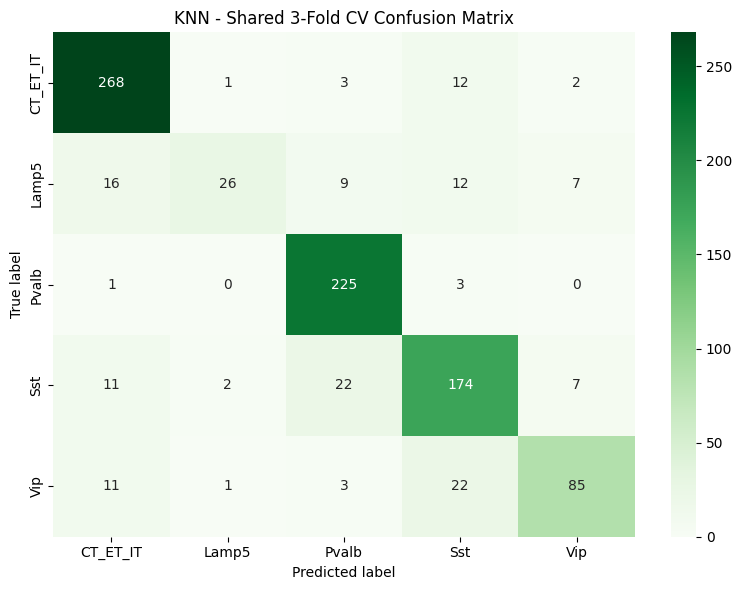


KNN - FINAL_TEST_SHARED
Accuracy: 0.8918
Balanced Accuracy: 0.8532
Macro F1: 0.8737
n_samples: 231

Classification report:
              precision    recall  f1-score   support

    CT_ET_IT     0.9710    0.9306    0.9504        72
       Lamp5     1.0000    0.6667    0.8000        18
       Pvalb     0.8462    0.9649    0.9016        57
         Sst     0.8103    0.8704    0.8393        54
         Vip     0.9259    0.8333    0.8772        30

    accuracy                         0.8918       231
   macro avg     0.9107    0.8532    0.8737       231
weighted avg     0.8990    0.8918    0.8912       231



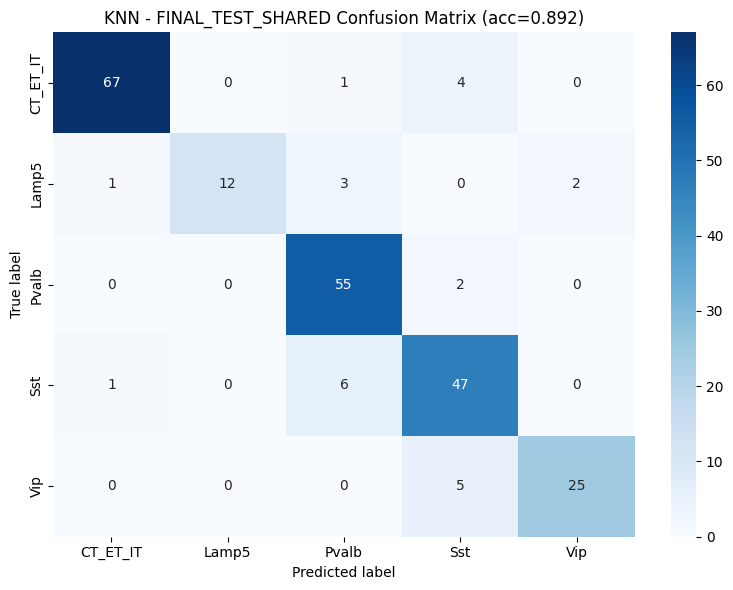



########################################
Running RandomForest
########################################

------------------------------
RandomForest Fold 1
------------------------------
Val Accuracy: 0.9318
Val Balanced Accuracy: 0.8905
Val Macro F1: 0.9091
Train samples: 615
Val samples: 308

------------------------------
RandomForest Fold 2
------------------------------
Val Accuracy: 0.9156
Val Balanced Accuracy: 0.8833
Val Macro F1: 0.8981
Train samples: 615
Val samples: 308

------------------------------
RandomForest Fold 3
------------------------------
Val Accuracy: 0.8795
Val Balanced Accuracy: 0.8232
Val Macro F1: 0.8455
Train samples: 616
Val samples: 307


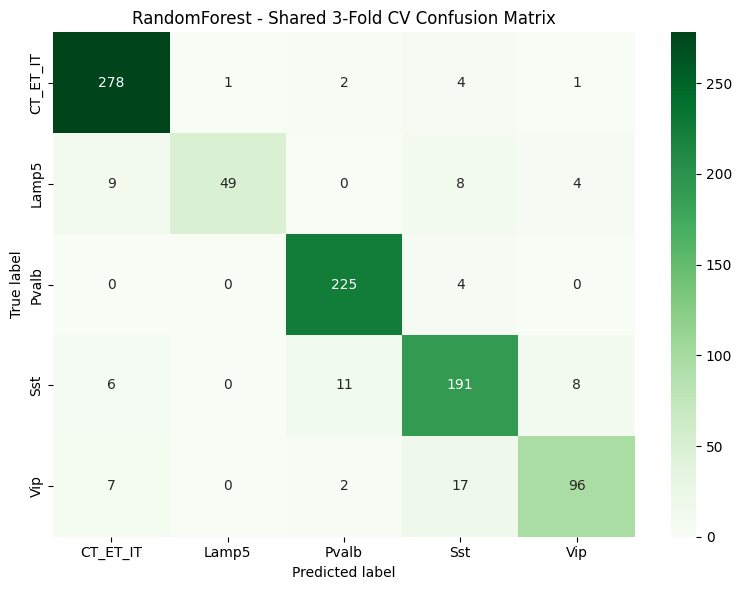


RandomForest - FINAL_TEST_SHARED
Accuracy: 0.9351
Balanced Accuracy: 0.8881
Macro F1: 0.9098
n_samples: 231

Classification report:
              precision    recall  f1-score   support

    CT_ET_IT     0.9600    1.0000    0.9796        72
       Lamp5     1.0000    0.6667    0.8000        18
       Pvalb     0.9194    1.0000    0.9580        57
         Sst     0.8909    0.9074    0.8991        54
         Vip     0.9630    0.8667    0.9123        30

    accuracy                         0.9351       231
   macro avg     0.9466    0.8881    0.9098       231
weighted avg     0.9373    0.9351    0.9327       231



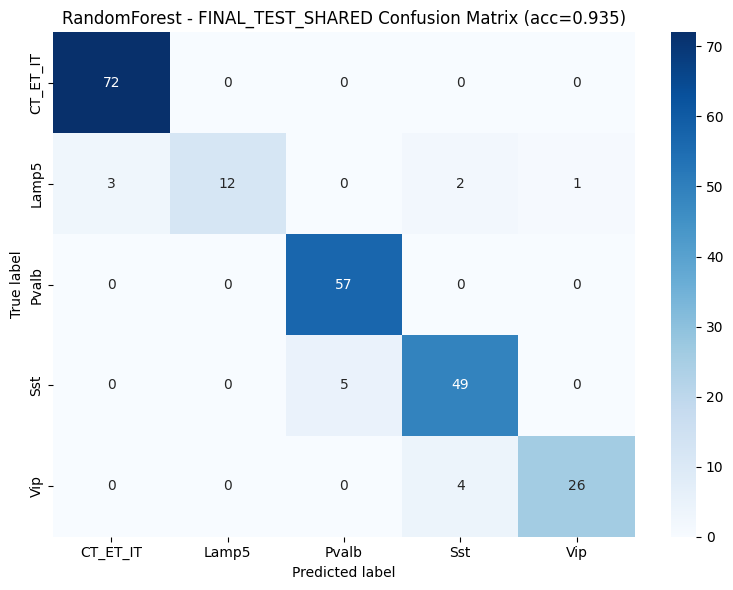



########################################
Running SVM
########################################

------------------------------
SVM Fold 1
------------------------------
Val Accuracy: 0.9513
Val Balanced Accuracy: 0.9285
Val Macro F1: 0.939
Train samples: 615
Val samples: 308

------------------------------
SVM Fold 2
------------------------------
Val Accuracy: 0.8864
Val Balanced Accuracy: 0.8641
Val Macro F1: 0.8573
Train samples: 615
Val samples: 308

------------------------------
SVM Fold 3
------------------------------
Val Accuracy: 0.9218
Val Balanced Accuracy: 0.9008
Val Macro F1: 0.908
Train samples: 616
Val samples: 307


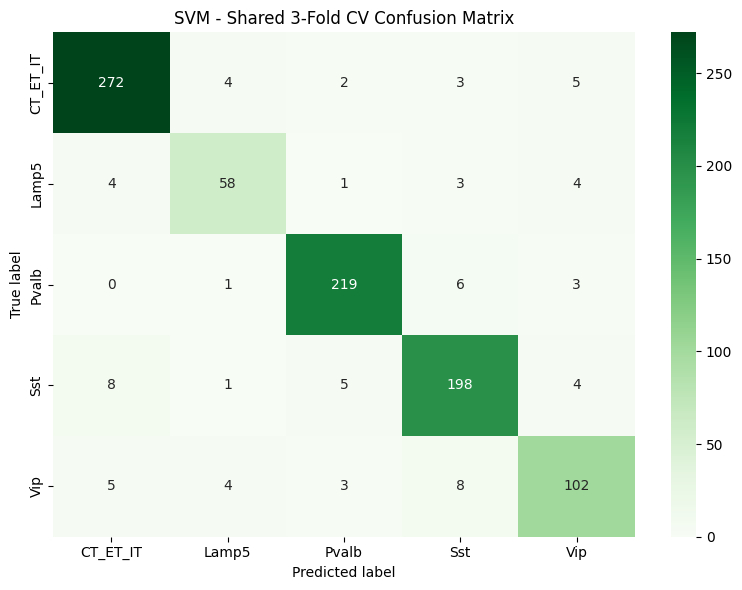


SVM - FINAL_TEST_SHARED
Accuracy: 0.9481
Balanced Accuracy: 0.9378
Macro F1: 0.9405
n_samples: 231

Classification report:
              precision    recall  f1-score   support

    CT_ET_IT     0.9857    0.9583    0.9718        72
       Lamp5     0.9412    0.8889    0.9143        18
       Pvalb     0.9492    0.9825    0.9655        57
         Sst     0.9091    0.9259    0.9174        54
         Vip     0.9333    0.9333    0.9333        30

    accuracy                         0.9481       231
   macro avg     0.9437    0.9378    0.9405       231
weighted avg     0.9485    0.9481    0.9481       231



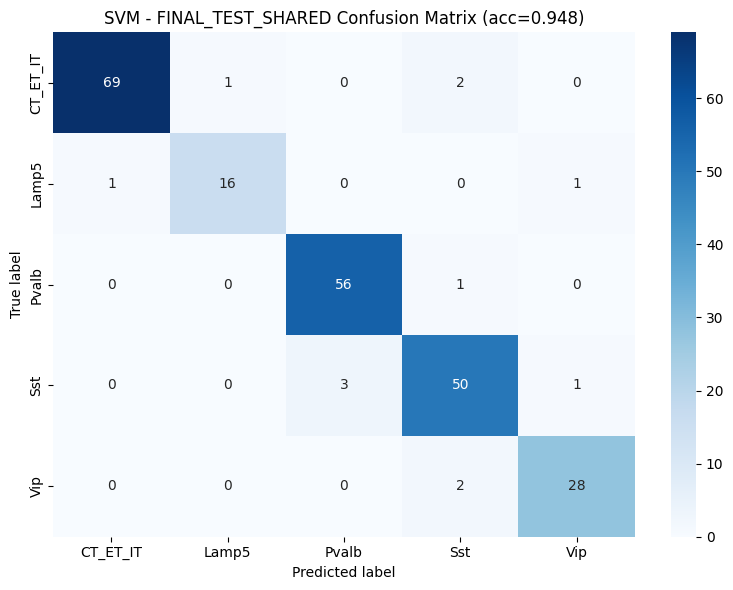


FINAL CV SUMMARY


,model,cv_mean_accuracy,cv_std_accuracy,cv_mean_balanced_accuracy,cv_mean_macro_f1,fold_accuracies
0,KNN,0.842908,0.013441,0.758707,0.777696,"[0.8538961038961039, 0.827922077922078, 0.8469..."
1,RandomForest,0.908960,0.026791,0.865676,0.884218,"[0.9318181818181818, 0.9155844155844156, 0.879..."
2,SVM,0.919829,0.032513,0.897775,0.901422,"[0.9512987012987013, 0.8863636363636364, 0.921..."



FINAL TEST SUMMARY


,model,split,accuracy,balanced_accuracy,macro_f1,n_samples
0,KNN,FINAL_TEST_SHARED,0.891775,0.853168,0.873695,231
1,RandomForest,FINAL_TEST_SHARED,0.935065,0.888148,0.909788,231
2,SVM,FINAL_TEST_SHARED,0.948052,0.937788,0.940480,231



TOP RANDOM FOREST FEATURES


,feature,importance
27,Upstroke-to-downstroke ratio,0.142298
6,AP width (ms),0.097814
1,AP amplitude (mV),0.072993
2,AP amplitude adaptation index,0.069141
14,Input resistance (MOhm),0.067680
17,Max number of APs,0.063938
18,Membrane time constant (ms),0.047946
8,Afterhyperpolarization (mV),0.040915
12,ISI average adaptation index,0.039694
10,ISI Fano factor,0.036153


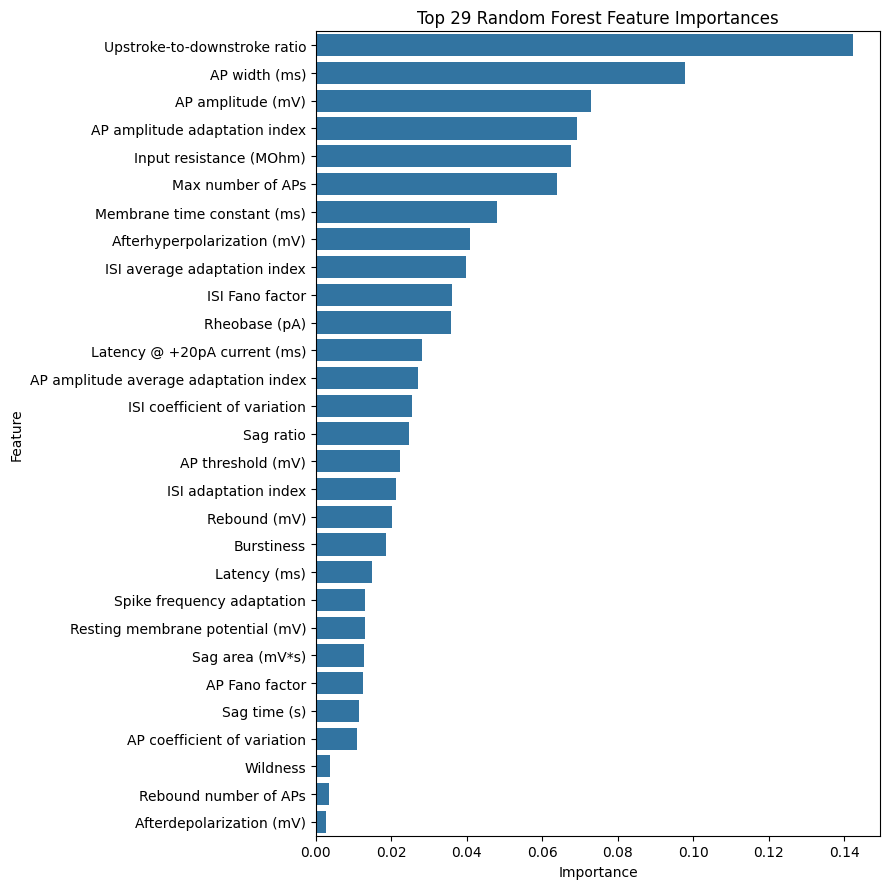


All KNN/RF shared-split outputs saved to:
/content/thesis_results_KNN_RF_shared_fair_split


In [ ]:
# ============================================================
# FAIR KNN + RANDOM FOREST + SVM ON PREDEFINED EPHYS FEATURES
# Uses the exact same shared final test set and same fold_id as deep learning
# ============================================================

import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

FEATURE_CSV = "/content/m1_patchseq_ephys_features.csv"

SHARED_SPLIT_DIR = "/content/shared_fair_splits"
RESULT_DIR = "/content/thesis_results_KNN_RF_shared_fair_split"

os.makedirs(RESULT_DIR, exist_ok=True)

SEED = 42
K_NEIGHBORS = 25
KNN_METRIC = "cosine"

random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# HELPER
# ------------------------------------------------------------

def any_to_short_id(x):
    x = str(x)

    m = re.search(r"ses-(\d+)-sample-(\d+)", x)
    if m:
        return f"{m.group(1)}_sample_{m.group(2)}"

    m = re.search(r"(\d+)_sample_(\d+)", x)
    if m:
        return f"{m.group(1)}_sample_{m.group(2)}"

    return None

# ------------------------------------------------------------
# 1) LOAD SHARED SPLIT
# ------------------------------------------------------------

shared_cv_path = os.path.join(SHARED_SPLIT_DIR, "shared_cv_pool.csv")
shared_test_path = os.path.join(SHARED_SPLIT_DIR, "shared_final_test_set.csv")

if not os.path.exists(shared_cv_path):
    raise FileNotFoundError(
        "shared_cv_pool.csv not found. Run the shared split cell first."
    )

if not os.path.exists(shared_test_path):
    raise FileNotFoundError(
        "shared_final_test_set.csv not found. Run the shared split cell first."
    )

shared_cv = pd.read_csv(shared_cv_path)
shared_test = pd.read_csv(shared_test_path)

required_split_cols = {"short_id", "RNA_family"}
if not required_split_cols.issubset(shared_cv.columns):
    raise ValueError("shared_cv_pool.csv must contain short_id and RNA_family.")

if not required_split_cols.issubset(shared_test.columns):
    raise ValueError("shared_final_test_set.csv must contain short_id and RNA_family.")

if "fold_id" not in shared_cv.columns:
    raise ValueError("shared_cv_pool.csv must contain fold_id.")

shared_cv["short_id"] = shared_cv["short_id"].astype(str)
shared_test["short_id"] = shared_test["short_id"].astype(str)

classes = sorted(shared_cv["RNA_family"].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

print("Shared split loaded")
print("CV pool:", len(shared_cv))
print("Final test:", len(shared_test))
print("Classes:", classes)

# ------------------------------------------------------------
# 2) LOAD PREDEFINED EPHYS FEATURES
# ------------------------------------------------------------

feat = pd.read_csv(FEATURE_CSV)

best_feat_id_col = max(
    feat.columns,
    key=lambda c: feat[c].astype(str).apply(any_to_short_id).notna().sum()
)

print("\nDetected feature ID column:", best_feat_id_col)

feat["short_id"] = feat[best_feat_id_col].apply(any_to_short_id)
feat = feat.dropna(subset=["short_id"]).copy()
feat = feat.drop_duplicates(subset=["short_id"]).reset_index(drop=True)

# ------------------------------------------------------------
# 3) MERGE FEATURES WITH SHARED SPLIT
# ------------------------------------------------------------

df_cv = shared_cv[["short_id", "RNA_family", "fold_id"]].merge(
    feat,
    on="short_id",
    how="inner"
)

df_test = shared_test[["short_id", "RNA_family"]].merge(
    feat,
    on="short_id",
    how="inner"
)

df_cv = df_cv.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("\nAfter merging shared split with features:")
print("KNN/RF CV pool:", len(df_cv))
print("KNN/RF final test:", len(df_test))

# These checks force exact fairness
if len(df_cv) != len(shared_cv):
    missing_cv = set(shared_cv["short_id"]) - set(df_cv["short_id"])
    raise ValueError(
        f"KNN/RF CV pool is not identical to shared CV pool. "
        f"Missing feature rows: {len(missing_cv)}"
    )

if len(df_test) != len(shared_test):
    missing_test = set(shared_test["short_id"]) - set(df_test["short_id"])
    raise ValueError(
        f"KNN/RF final test is not identical to shared final test. "
        f"Missing feature rows: {len(missing_test)}"
    )

print("\nExact shared split confirmed for KNN/RF.")

# ------------------------------------------------------------
# 4) CHOOSE PREDEFINED FEATURES
# ------------------------------------------------------------

# Leave empty to use all numeric predefined/ephys features.
# Or manually write feature names inside the list.
PREDEFINED_FEATURES = [
    # "Upstroke-to-downstroke ratio",
    # "AP width (ms)",
    # "AP amplitude (mV)",
    # "Max number of APs",
    # "Input resistance (MOhm)",
]

# Exclude ID, label, split, and possible leakage columns
leakage_keywords = [
    "rna",
    "family",
    "label",
    "class",
    "subclass",
    "cluster",
    "type",
    "transcriptomic",
    "cre",
    "marker"
]

excluded_cols = {
    "short_id",
    "RNA_family",
    "fold_id",
    best_feat_id_col
}

all_numeric_features = []

for c in df_cv.columns:
    c_lower = c.lower()

    if c in excluded_cols:
        continue

    if any(key in c_lower for key in leakage_keywords):
        continue

    if pd.api.types.is_numeric_dtype(df_cv[c]):
        all_numeric_features.append(c)

if len(PREDEFINED_FEATURES) > 0:
    selected_features = [f for f in PREDEFINED_FEATURES if f in all_numeric_features]

    missing_features = [f for f in PREDEFINED_FEATURES if f not in all_numeric_features]
    if len(missing_features) > 0:
        print("\nWarning: these selected features were not found or were excluded:")
        print(missing_features)

    if len(selected_features) == 0:
        raise ValueError("No valid predefined features were selected.")

    print("\nUsing manually selected predefined features.")

else:
    selected_features = all_numeric_features
    print("\nUsing all numeric predefined/ephys features.")

print("Number of features used:", len(selected_features))
print(selected_features)

# ------------------------------------------------------------
# 5) BUILD X AND y
# ------------------------------------------------------------

def make_xy(d):
    X = d[selected_features].values
    y = d["RNA_family"].map(class_to_idx).values
    return X, y

X_test, y_test = make_xy(df_test)

# ------------------------------------------------------------
# 6) DEFINE MODELS
# ------------------------------------------------------------

models = {
    "KNN": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(
            n_neighbors=K_NEIGHBORS,
            metric=KNN_METRIC
        ))
    ]),

    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        ))
    ]),

    "SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=10.0,
            gamma="scale",
            class_weight="balanced",
            random_state=SEED
        ))
    ])
}

# ------------------------------------------------------------
# 7) PLOTTING AND EVALUATION HELPERS
# ------------------------------------------------------------

def save_confusion_matrix(cm, title, save_path, cmap="Blues"):

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=classes,
        yticklabels=classes,
        cmap=cmap
    )

    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


def evaluate_predictions(y_true, y_pred, model_name, split_name):

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print("\n==============================")
    print(f"{model_name} - {split_name}")
    print("==============================")
    print("Accuracy:", round(acc, 4))
    print("Balanced Accuracy:", round(bal_acc, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("n_samples:", len(y_true))

    report = classification_report(
        y_true,
        y_pred,
        target_names=classes,
        digits=4
    )

    print("\nClassification report:")
    print(report)

    report_path = os.path.join(
        RESULT_DIR,
        f"{model_name}_{split_name}_classification_report.txt"
    )

    with open(report_path, "w") as f:
        f.write(report)

    cm = confusion_matrix(y_true, y_pred)

    save_confusion_matrix(
        cm=cm,
        title=f"{model_name} - {split_name} Confusion Matrix (acc={acc:.3f})",
        save_path=os.path.join(
            RESULT_DIR,
            f"{model_name}_{split_name}_confusion_matrix.png"
        ),
        cmap="Blues"
    )

    return {
        "model": model_name,
        "split": split_name,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "macro_f1": macro_f1,
        "n_samples": len(y_true)
    }

# ------------------------------------------------------------
# 8) TRAIN WITH SAME FOLDS AND EVALUATE SAME FINAL TEST
# ------------------------------------------------------------

cv_summary = []
test_summary = []

fold_ids = sorted(df_cv["fold_id"].unique())

for model_name, model in models.items():

    print("\n\n########################################")
    print(f"Running {model_name}")
    print("########################################")

    fold_results = []
    y_true_cv_all = []
    y_pred_cv_all = []

    for fold in fold_ids:

        train_df = df_cv[df_cv["fold_id"] != fold].reset_index(drop=True)
        val_df = df_cv[df_cv["fold_id"] == fold].reset_index(drop=True)

        X_train, y_train = make_xy(train_df)
        X_val, y_val = make_xy(val_df)

        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)

        acc = accuracy_score(y_val, y_val_pred)
        bal_acc = balanced_accuracy_score(y_val, y_val_pred)
        macro_f1 = f1_score(y_val, y_val_pred, average="macro")

        print("\n------------------------------")
        print(f"{model_name} Fold {fold}")
        print("------------------------------")
        print("Val Accuracy:", round(acc, 4))
        print("Val Balanced Accuracy:", round(bal_acc, 4))
        print("Val Macro F1:", round(macro_f1, 4))
        print("Train samples:", len(train_df))
        print("Val samples:", len(val_df))

        fold_results.append({
            "model": model_name,
            "fold": int(fold),
            "val_accuracy": acc,
            "val_balanced_accuracy": bal_acc,
            "val_macro_f1": macro_f1,
            "n_train": len(train_df),
            "n_val": len(val_df)
        })

        y_true_cv_all.extend(y_val.tolist())
        y_pred_cv_all.extend(y_val_pred.tolist())

    # CV confusion matrix from all validation folds
    cm_cv = confusion_matrix(y_true_cv_all, y_pred_cv_all)

    save_confusion_matrix(
        cm=cm_cv,
        title=f"{model_name} - Shared 3-Fold CV Confusion Matrix",
        save_path=os.path.join(
            RESULT_DIR,
            f"{model_name}_shared_CV_confusion_matrix.png"
        ),
        cmap="Greens"
    )

    fold_df = pd.DataFrame(fold_results)

    cv_summary.append({
        "model": model_name,
        "cv_mean_accuracy": fold_df["val_accuracy"].mean(),
        "cv_std_accuracy": fold_df["val_accuracy"].std(),
        "cv_mean_balanced_accuracy": fold_df["val_balanced_accuracy"].mean(),
        "cv_mean_macro_f1": fold_df["val_macro_f1"].mean(),
        "fold_accuracies": fold_df["val_accuracy"].tolist()
    })

    fold_df.to_csv(
        os.path.join(RESULT_DIR, f"{model_name}_shared_CV_fold_results.csv"),
        index=False
    )

    # Train final model on the whole shared CV pool
    X_cv_all, y_cv_all = make_xy(df_cv)

    model.fit(X_cv_all, y_cv_all)

    # Evaluate on the exact shared final test set
    y_test_pred = model.predict(X_test)

    test_result = evaluate_predictions(
        y_true=y_test,
        y_pred=y_test_pred,
        model_name=model_name,
        split_name="FINAL_TEST_SHARED"
    )

    test_summary.append(test_result)

# ------------------------------------------------------------
# 9) SAVE SUMMARIES
# ------------------------------------------------------------

cv_summary_df = pd.DataFrame(cv_summary)
test_summary_df = pd.DataFrame(test_summary)

print("\n==============================")
print("FINAL CV SUMMARY")
print("==============================")
display(cv_summary_df)

print("\n==============================")
print("FINAL TEST SUMMARY")
print("==============================")
display(test_summary_df)

cv_summary_df.to_csv(
    os.path.join(RESULT_DIR, "KNN_RF_shared_CV_summary.csv"),
    index=False
)

test_summary_df.to_csv(
    os.path.join(RESULT_DIR, "KNN_RF_shared_FINAL_TEST_summary.csv"),
    index=False
)

# ------------------------------------------------------------
# 10) RANDOM FOREST FEATURE IMPORTANCE
# ------------------------------------------------------------

rf_model = models["RandomForest"]
rf_importances = rf_model.named_steps["rf"].feature_importances_  # RF only

importance_df = pd.DataFrame({
    "feature": selected_features,
    "importance": rf_importances
}).sort_values("importance", ascending=False)

print("\n==============================")
print("TOP RANDOM FOREST FEATURES")
print("==============================")
display(importance_df.head(30))

importance_df.to_csv(
    os.path.join(RESULT_DIR, "RandomForest_feature_importance.csv"),
    index=False
)

plt.figure(figsize=(9, 9))

top_n = min(30, len(importance_df))

sns.barplot(
    data=importance_df.head(top_n),
    x="importance",
    y="feature"
)

plt.title(f"Top {top_n} Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    os.path.join(RESULT_DIR, "RandomForest_top_feature_importance.png"),
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# 11) SAVE JSON SUMMARY
# ------------------------------------------------------------

summary = {
    "shared_split_dir": SHARED_SPLIT_DIR,
    "result_dir": RESULT_DIR,
    "classes": classes,
    "n_cv_pool": int(len(df_cv)),
    "n_final_test": int(len(df_test)),
    "selected_features": selected_features,
    "cv_summary": cv_summary,
    "test_summary": test_summary
}

with open(os.path.join(RESULT_DIR, "KNN_RF_shared_summary.json"), "w") as f:
    json.dump(summary, f, indent=4)

print("\nAll KNN/RF shared-split outputs saved to:")
print(RESULT_DIR)

## Step 5 — Deep learning on WST S1 representations

The three CNNs take the WST **S1** coefficients (resized to 224×224 and repeated to 3
channels) as input. Each model runs the shared 3-fold cross-validation, retrains on the
whole CV pool, and is evaluated on the shared final test set.

### ResNet18

In [ ]:
# ============================================================
# RESNET18 WITH SHARED FAIR SPLIT
# Same final test set for:
# KNN / Random Forest / ResNet18 / VGG16 / Inception
# ============================================================

import os, re, glob, json, random
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt

# ============================================================
# 1) USER SETTINGS & PATHS
# ============================================================

META_PATH = "/content/m1_patchseq_meta_data (1).csv"  # TAB-delimited metadata
NPZ_DIR   = "/content/WST_kept_cells_sweeps010_070_cut2500_17500_J12_Q20/per_cell_npz"
FEATURE_CSV = "/content/m1_patchseq_ephys_features.csv"

SHARED_SPLIT_DIR = "/content/shared_fair_splits"
OUTDIR = "/content/cross_val_results_Resnet18_shared_fair"

os.makedirs(SHARED_SPLIT_DIR, exist_ok=True)
os.makedirs(OUTDIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Hyperparameters
K_FOLDS = 3
TEST_SIZE = 0.20
BATCH_SIZE = 32
NUM_WORKERS = 2
IMG_SIZE = 224
NUM_EPOCHS = 25
LR = 3e-4
WEIGHT_DECAY = 1e-4
DROPOUT_P = 0.25
LABEL_SMOOTH = 0.05
MIXUP_ALPHA = 0.1
EARLY_STOP_PATIENCE = 10
MIN_SAMPLES_PER_CLASS = 20

# ============================================================
# 2) REPRODUCIBILITY HELPERS
# ============================================================

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# ============================================================
# 3) LABEL AND ID HELPERS
# ============================================================

MERGE_MAP = {
    "CT": "CT_ET_IT",
    "ET": "CT_ET_IT",
    "IT": "CT_ET_IT",
    "CTandET": "CT_ET_IT",
    "ITandET": "CT_ET_IT",
}

def merge_family_label(lbl):
    if lbl is None:
        return None
    lbl = str(lbl).strip()
    return MERGE_MAP.get(lbl, lbl)

def any_to_short_id(x):
    x = str(x)

    m = re.search(r"ses-(\d+)-sample-(\d+)", x)
    if m:
        return f"{m.group(1)}_sample_{m.group(2)}"

    m = re.search(r"(\d+)_sample_(\d+)", x)
    if m:
        return f"{m.group(1)}_sample_{m.group(2)}"

    return None

def meta_to_short_id(x):
    return any_to_short_id(x)

def npz_to_short_id(npz_path):
    try:
        z = np.load(npz_path, allow_pickle=True)

        if "short_id" in z:
            v = z["short_id"]

            if isinstance(v, np.ndarray):
                v = v.item() if v.size == 1 else v[0]

            sid = str(v).strip()

            if sid != "":
                return sid

    except Exception:
        pass

    return any_to_short_id(os.path.basename(npz_path))

# ============================================================
# 4) DATASET CLASS
# ============================================================

class WST_S1_Dataset(Dataset):
    def __init__(self, df, class_to_idx, img_size=224):
        self.df = df.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        z = np.load(row["npz_path"], allow_pickle=True)

        if "S1" not in z:
            raise KeyError(f"S1 not found in NPZ file: {row['npz_path']}")

        S1 = z["S1"].astype(np.float32)

        # Per-sample normalization
        S1 = (S1 - S1.mean()) / (S1.std() + 1e-6)

        # [H,W] -> [1,1,H,W] -> resize -> repeat to 3 channels -> [3,H,W]
        x = torch.from_numpy(S1)[None, None, :, :]
        x = F.interpolate(
            x,
            size=(self.img_size, self.img_size),
            mode="bilinear",
            align_corners=False
        )

        x = x.repeat(1, 3, 1, 1).squeeze(0)

        y = torch.tensor(
            self.class_to_idx[row["RNA_family"]],
            dtype=torch.long
        )

        return x, y

# ============================================================
# 5) MODEL AND TRAINING HELPERS
# ============================================================

def get_model(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(DROPOUT_P),
        nn.Linear(in_features, num_classes)
    )

    return model.to(DEVICE)

def mixup_batch(x, y, alpha=0.2):
    if alpha is None or alpha <= 0:
        return x, y, None, 1.0

    lam = np.random.beta(alpha, alpha)
    perm = torch.randperm(x.size(0), device=x.device)

    x_mix = lam * x + (1 - lam) * x[perm]

    return x_mix, y, y[perm], lam

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total = 0

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        x_mix, y1, y2, lam = mixup_batch(x, y, alpha=MIXUP_ALPHA)

        optimizer.zero_grad()

        logits = model(x_mix)

        if y2 is None:
            loss = criterion(logits, y1)
        else:
            loss = lam * criterion(logits, y1) + (1 - lam) * criterion(logits, y2)

        loss.backward()
        optimizer.step()

        preds = logits.argmax(1)

        total_correct += (preds == y).sum().item()
        total_loss += loss.item() * x.size(0)
        total += x.size(0)

    return total_loss / max(total, 1), total_correct / max(total, 1)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(x)
        loss = criterion(logits, y)

        preds = logits.argmax(1)

        total_correct += (preds == y).sum().item()
        total_loss += loss.item() * x.size(0)
        total += x.size(0)

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(y.detach().cpu().numpy().tolist())

    return (
        total_loss / max(total, 1),
        total_correct / max(total, 1),
        all_labels,
        all_preds
    )

# ============================================================
# 6) PLOTTING HELPERS
# ============================================================

def save_confusion_matrix_png(cm, class_names, out_png, title):
    plt.figure(figsize=(1.3 * len(class_names), 1.1 * len(class_names)))

    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))

    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    thresh = cm.max() * 0.5 if cm.max() > 0 else 0.5

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

def save_loss_curves_png(history_df, out_png, title):
    plt.figure(figsize=(7, 5))

    plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")

    if "val_loss" in history_df.columns:
        plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

def save_acc_curves_png(history_df, out_png, title):
    plt.figure(figsize=(7, 5))

    plt.plot(history_df["epoch"], history_df["train_acc"], label="train_acc")

    if "val_acc" in history_df.columns:
        plt.plot(history_df["epoch"], history_df["val_acc"], label="val_acc")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

# ============================================================
# 7) LOAD METADATA AND NPZ DATAFRAME
# ============================================================

print("\n--- Loading metadata ---")

meta = pd.read_csv(META_PATH, sep="\t")

rna_cols = [
    c for c in meta.columns
    if c.strip().lower().replace(" ", "") == "rnafamily"
]

if len(rna_cols) == 0:
    raise ValueError("Could not find a column named RNA family / RNAfamily in metadata.")

rna_col = rna_cols[0]

meta["short_id"] = meta["Cell"].astype(str).apply(meta_to_short_id)
meta = meta.dropna(subset=["short_id"]).copy()

meta["RNA_family"] = meta[rna_col].astype(str).str.strip()
meta["RNA_family"] = meta["RNA_family"].apply(merge_family_label)

meta = meta[meta["RNA_family"].str.lower() != "low quality"].copy()
meta = meta.drop_duplicates(subset=["short_id"]).reset_index(drop=True)

rna_map = dict(zip(meta["short_id"], meta["RNA_family"]))

print("Metadata usable cells:", len(meta))
print(meta["RNA_family"].value_counts())

print("\n--- Indexing NPZ files ---")

npz_paths = sorted(glob.glob(os.path.join(NPZ_DIR, "*.npz")))

rows = []

for p in npz_paths:
    sid = npz_to_short_id(p)

    if sid is None:
        continue

    fam = rna_map.get(sid, None)

    if fam is None:
        continue

    fam = merge_family_label(fam)

    if str(fam).strip().lower() == "low quality":
        continue

    rows.append({
        "npz_path": p,
        "short_id": sid,
        "RNA_family": fam
    })

df_all = pd.DataFrame(rows)

if len(df_all) == 0:
    raise ValueError("No usable NPZ samples found after mapping NPZ files to metadata labels.")

df_all = df_all.drop_duplicates(subset=["short_id"]).reset_index(drop=True)

print("\nNPZ + metadata samples before shared filtering:", len(df_all))
print(df_all["RNA_family"].value_counts())

# ============================================================
# 8) LOAD THE SHARED FAIR SPLIT
#    Created once by the "Build the shared fair split" cell.
#    Every model loads the SAME split, so the comparison is fair.
# ============================================================

shared_cv_path   = os.path.join(SHARED_SPLIT_DIR, "shared_cv_pool.csv")
shared_test_path = os.path.join(SHARED_SPLIT_DIR, "shared_final_test_set.csv")

if not (os.path.exists(shared_cv_path) and os.path.exists(shared_test_path)):
    raise FileNotFoundError(
        "Shared fair split not found in "
        f"{SHARED_SPLIT_DIR}. Run the 'Build the shared fair split' cell "
        "once before running any model cell."
    )

print("\n--- Loading shared fair split ---")

shared_cv   = pd.read_csv(shared_cv_path)
shared_test = pd.read_csv(shared_test_path)

required_cv_cols   = {"short_id", "RNA_family", "fold_id"}
required_test_cols = {"short_id", "RNA_family"}

if not required_cv_cols.issubset(shared_cv.columns):
    raise ValueError("shared_cv_pool.csv must contain short_id, RNA_family and fold_id.")

if not required_test_cols.issubset(shared_test.columns):
    raise ValueError("shared_final_test_set.csv must contain short_id and RNA_family.")

# ============================================================
# 9) ATTACH NPZ PATHS TO SHARED SPLIT
# ============================================================

def attach_npz_paths(split_df, split_name):
    needed_cols = ["short_id", "npz_path"]

    merged = split_df.merge(
        df_all[needed_cols],
        on="short_id",
        how="inner"
    )

    if len(merged) != len(split_df):
        missing_ids = set(split_df["short_id"]) - set(merged["short_id"])

        raise ValueError(
            f"{split_name} is not fully available in NPZ dataframe. "
            f"Missing NPZ rows: {len(missing_ids)}"
        )

    return merged.reset_index(drop=True)

shared_cv["short_id"] = shared_cv["short_id"].astype(str)
shared_test["short_id"] = shared_test["short_id"].astype(str)

df_cv = attach_npz_paths(shared_cv[["short_id", "RNA_family", "fold_id"]], "CV pool")
df_test = attach_npz_paths(shared_test[["short_id", "RNA_family"]], "Final test")

df_cv = df_cv.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

classes = sorted(pd.concat([df_cv["RNA_family"], df_test["RNA_family"]]).unique().tolist())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

print("\n==============================")
print("FINAL SHARED SPLIT USED BY RESNET18")
print("==============================")
print("CV pool:", len(df_cv))
print("Final test:", len(df_test))
print("Classes:", classes)

print("\nCV class counts:")
print(df_cv["RNA_family"].value_counts())

print("\nFinal test class counts:")
print(df_test["RNA_family"].value_counts())

df_cv.to_csv(os.path.join(OUTDIR, "cv_pool_used_by_ResNet18.csv"), index=False)
df_test.to_csv(os.path.join(OUTDIR, "final_test_set_used_by_ResNet18.csv"), index=False)

# ============================================================
# 10) K-FOLD CROSS VALIDATION USING SHARED FOLD_ID
# ============================================================

fold_ids = sorted(df_cv["fold_id"].unique())

fold_best_acc = []
fold_best_epoch = []
fold_model_paths = []
all_fold_summaries = []

for fold in fold_ids:

    print("\n==============================")
    print(f"FOLD {fold}/{len(fold_ids)}")
    print("==============================")

    fold_dir = os.path.join(OUTDIR, f"fold_{int(fold)}")
    os.makedirs(fold_dir, exist_ok=True)

    train_sub = df_cv[df_cv["fold_id"] != fold].copy().reset_index(drop=True)
    val_sub = df_cv[df_cv["fold_id"] == fold].copy().reset_index(drop=True)

    print("Train samples:", len(train_sub))
    print("Val samples:", len(val_sub))

    train_counts = (
        train_sub["RNA_family"]
        .value_counts()
        .reindex(classes)
        .fillna(0)
        .astype(int)
        .values
    )

    safe_counts = np.maximum(train_counts, 1)
    weights = (len(train_sub) / (len(classes) * safe_counts)).astype(np.float32)
    weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

    train_ds = WST_S1_Dataset(train_sub, class_to_idx, img_size=IMG_SIZE)
    val_ds = WST_S1_Dataset(val_sub, class_to_idx, img_size=IMG_SIZE)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker,
        generator=g
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker
    )

    model = get_model(len(classes))

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    criterion = nn.CrossEntropyLoss(
        weight=weights,
        label_smoothing=LABEL_SMOOTH
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    best_val_acc = -1.0
    best_epoch = -1
    patience_counter = 0
    best_model_path = os.path.join(fold_dir, "best_model.pth")

    history = []

    for epoch in range(1, NUM_EPOCHS + 1):

        tr_loss, tr_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        val_loss, val_acc, y_val_true, y_val_pred = evaluate(
            model,
            val_loader,
            criterion
        )

        scheduler.step(val_acc)

        history.append({
            "epoch": int(epoch),
            "train_loss": float(tr_loss),
            "train_acc": float(tr_acc),
            "val_loss": float(val_loss),
            "val_acc": float(val_acc),
            "lr": float(optimizer.param_groups[0]["lr"])
        })

        improved = val_acc > best_val_acc + 1e-6

        if improved:
            best_val_acc = val_acc
            best_epoch = epoch
            patience_counter = 0

            torch.save(model.state_dict(), best_model_path)

        else:
            patience_counter += 1

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={tr_loss:.4f} train_acc={tr_acc:.3f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.3f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}"
        )

        if patience_counter >= EARLY_STOP_PATIENCE:
            print(
                f"Early stopping at epoch {epoch} "
                f"(best epoch={best_epoch}, best val acc={best_val_acc:.4f})"
            )
            break

    hist_df = pd.DataFrame(history)

    hist_df.to_csv(os.path.join(fold_dir, "history.csv"), index=False)

    with open(os.path.join(fold_dir, "history.json"), "w") as f:
        json.dump(history, f, indent=2)

    save_loss_curves_png(
        hist_df,
        os.path.join(fold_dir, "loss_curve.png"),
        title=f"ResNet18 Fold {fold} Loss Curve"
    )

    save_acc_curves_png(
        hist_df,
        os.path.join(fold_dir, "acc_curve.png"),
        title=f"ResNet18 Fold {fold} Accuracy Curve"
    )

    best_model = get_model(len(classes))
    best_model.load_state_dict(
        torch.load(best_model_path, map_location=DEVICE)
    )
    best_model.eval()

    val_eval_criterion = nn.CrossEntropyLoss()

    val_loss_b, val_acc_b, y_val_true_b, y_val_pred_b = evaluate(
        best_model,
        val_loader,
        val_eval_criterion
    )

    cm_val = confusion_matrix(
        y_val_true_b,
        y_val_pred_b,
        labels=list(range(len(classes)))
    )

    pd.DataFrame(
        cm_val,
        index=classes,
        columns=classes
    ).to_csv(os.path.join(fold_dir, "val_confusion_matrix.csv"))

    save_confusion_matrix_png(
        cm_val,
        classes,
        os.path.join(fold_dir, "val_confusion_matrix.png"),
        title=f"ResNet18 Fold {fold} VAL Confusion Matrix (acc={val_acc_b:.3f})"
    )

    report = classification_report(
        y_val_true_b,
        y_val_pred_b,
        labels=list(range(len(classes))),
        target_names=classes,
        digits=4,
        zero_division=0
    )

    with open(os.path.join(fold_dir, "val_classification_report.txt"), "w") as f:
        f.write(report)

    fold_best_acc.append(float(best_val_acc))
    fold_best_epoch.append(int(best_epoch))
    fold_model_paths.append(best_model_path)

    all_fold_summaries.append({
        "fold": int(fold),
        "best_val_acc": float(best_val_acc),
        "best_epoch": int(best_epoch),
        "n_train": int(len(train_sub)),
        "n_val": int(len(val_sub))
    })

    print(f"\nFold {fold} summary:")
    print(f"  best_val_acc = {best_val_acc:.4f} at epoch {best_epoch}")
    print(f"  saved: {best_model_path}")
    print(f"  saved: {fold_dir}/loss_curve.png")
    print(f"  saved: {fold_dir}/acc_curve.png")
    print(f"  saved: {fold_dir}/val_confusion_matrix.png")

# ============================================================
# 11) SAVE CV SUMMARY
# ============================================================

cv_mean = float(np.mean(fold_best_acc))
cv_std = float(np.std(fold_best_acc))

recommended_final_epochs = int(np.round(np.median(fold_best_epoch)))
recommended_final_epochs = max(1, recommended_final_epochs)

cv_summary = {
    "model": "ResNet18",
    "k_folds": K_FOLDS,
    "fold_best_val_acc": fold_best_acc,
    "fold_best_epoch": fold_best_epoch,
    "cv_mean_best_val_acc": cv_mean,
    "cv_std_best_val_acc": cv_std,
    "recommended_final_epochs_median_best_epoch": recommended_final_epochs,
    "classes": classes,
    "n_cv_pool": int(len(df_cv)),
    "n_final_test": int(len(df_test)),
    "shared_split_dir": SHARED_SPLIT_DIR,
    "hyperparams": {
        "batch_size": BATCH_SIZE,
        "img_size": IMG_SIZE,
        "epochs_max": NUM_EPOCHS,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
        "dropout_p": DROPOUT_P,
        "label_smoothing": LABEL_SMOOTH,
        "mixup_alpha": MIXUP_ALPHA,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "min_samples_per_class": MIN_SAMPLES_PER_CLASS
    },
    "fold_details": all_fold_summaries
}

with open(os.path.join(OUTDIR, "cv_summary.json"), "w") as f:
    json.dump(cv_summary, f, indent=2)

print("\n==============================")
print("CROSS-VALIDATION SUMMARY")
print("==============================")
print(f"Fold best val acc: {np.round(fold_best_acc, 4).tolist()}")
print(f"CV mean(best val acc) = {cv_mean:.4f} ± {cv_std:.4f}")
print(f"Recommended final training epochs = {recommended_final_epochs}")
print(f"Saved CV summary to: {os.path.join(OUTDIR, 'cv_summary.json')}")

# ============================================================
# 12) TRAIN FINAL RESNET18 ON WHOLE SHARED CV POOL
# ============================================================

print("\n==============================")
print("TRAINING FINAL RESNET18 ON FULL SHARED CV POOL")
print("==============================")

final_dir = os.path.join(OUTDIR, "final_model")
os.makedirs(final_dir, exist_ok=True)

train_counts = (
    df_cv["RNA_family"]
    .value_counts()
    .reindex(classes)
    .fillna(0)
    .astype(int)
    .values
)

safe_counts = np.maximum(train_counts, 1)
weights = (len(df_cv) / (len(classes) * safe_counts)).astype(np.float32)
weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

final_train_ds = WST_S1_Dataset(df_cv, class_to_idx, img_size=IMG_SIZE)

final_train_loader = DataLoader(
    final_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
    generator=g
)

final_model = get_model(len(classes))

final_optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

final_criterion = nn.CrossEntropyLoss(
    weight=weights,
    label_smoothing=LABEL_SMOOTH
)

final_history = []

for epoch in range(1, recommended_final_epochs + 1):

    tr_loss, tr_acc = train_one_epoch(
        final_model,
        final_train_loader,
        final_optimizer,
        final_criterion
    )

    final_history.append({
        "epoch": int(epoch),
        "train_loss": float(tr_loss),
        "train_acc": float(tr_acc),
        "lr": float(final_optimizer.param_groups[0]["lr"])
    })

    print(
        f"Final Epoch {epoch:02d}/{recommended_final_epochs} | "
        f"train_loss={tr_loss:.4f} train_acc={tr_acc:.3f}"
    )

final_model_path = os.path.join(final_dir, "resnet18_final_trained_on_full_cv_pool.pth")
torch.save(final_model.state_dict(), final_model_path)

final_hist_df = pd.DataFrame(final_history)
final_hist_df.to_csv(os.path.join(final_dir, "final_training_history.csv"), index=False)

with open(os.path.join(final_dir, "final_training_history.json"), "w") as f:
    json.dump(final_history, f, indent=2)

save_loss_curves_png(
    final_hist_df,
    os.path.join(final_dir, "final_training_loss_curve.png"),
    title="ResNet18 Final Training Loss Curve"
)

save_acc_curves_png(
    final_hist_df,
    os.path.join(final_dir, "final_training_acc_curve.png"),
    title="ResNet18 Final Training Accuracy Curve"
)

# ============================================================
# 13) FINAL EVALUATION ON EXACT SHARED FINAL TEST SET
# ============================================================

print("\n==============================")
print("FINAL TEST EVALUATION ON SHARED FINAL TEST SET")
print("==============================")

test_ds = WST_S1_Dataset(df_test, class_to_idx, img_size=IMG_SIZE)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker
)

test_criterion = nn.CrossEntropyLoss()

test_loss, test_acc, y_true, y_pred = evaluate(
    final_model,
    test_loader,
    test_criterion
)

print(f"Final shared test samples = {len(df_test)}")
print(f"Test loss = {test_loss:.4f}")
print(f"Test acc  = {test_acc:.4f}")

test_report = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(classes))),
    target_names=classes,
    digits=4,
    zero_division=0
)

print("\nClassification report:")
print(test_report)

with open(os.path.join(OUTDIR, "final_test_classification_report.txt"), "w") as f:
    f.write(test_report)

cm_test = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(len(classes)))
)

pd.DataFrame(
    cm_test,
    index=classes,
    columns=classes
).to_csv(os.path.join(OUTDIR, "final_test_confusion_matrix.csv"))

save_confusion_matrix_png(
    cm_test,
    classes,
    os.path.join(OUTDIR, "final_test_confusion_matrix.png"),
    title=f"ResNet18 FINAL SHARED TEST Confusion Matrix (acc={test_acc:.3f})"
)

# ============================================================
# 14) SAVE FINAL METRICS
# ============================================================

final_metrics = {
    "model": "ResNet18",
    "shared_split_dir": SHARED_SPLIT_DIR,
    "outdir": OUTDIR,
    "n_cv_pool": int(len(df_cv)),
    "n_final_test": int(len(df_test)),
    "classes": classes,
    "fold_best_val_acc": fold_best_acc,
    "fold_best_epoch": fold_best_epoch,
    "cv_mean_best_val_acc": cv_mean,
    "cv_std_best_val_acc": cv_std,
    "recommended_final_epochs": int(recommended_final_epochs),
    "final_test_loss": float(test_loss),
    "final_test_acc": float(test_acc),
    "final_model_path": final_model_path
}

with open(os.path.join(OUTDIR, "final_metrics.json"), "w") as f:
    json.dump(final_metrics, f, indent=2)

print("\n==============================")
print("DONE")
print("==============================")
print("Saved thesis-ready outputs to:")
print(OUTDIR)

print("\nImportant files:")
print("  - cv_summary.json")
print("  - fold_*/loss_curve.png")
print("  - fold_*/acc_curve.png")
print("  - fold_*/val_confusion_matrix.png")
print("  - final_model/final_training_loss_curve.png")
print("  - final_model/final_training_acc_curve.png")
print("  - final_test_confusion_matrix.png")
print("  - final_test_classification_report.txt")
print("  - final_metrics.json")

print("\nCheck this number and compare it with KNN/RF:")
print("Final shared test samples =", len(df_test))


--- Loading metadata ---
Metadata usable cells: 1232
RNA_family
CT_ET_IT    409
Pvalb       289
Sst         272
Vip         153
Lamp5        91
Sncg         13
NP            5
Name: count, dtype: int64

--- Indexing NPZ files ---

NPZ + metadata samples before shared filtering: 1172
RNA_family
CT_ET_IT    358
Pvalb       286
Sst         270
Vip         152
Lamp5        88
Sncg         13
NP            5
Name: count, dtype: int64

--- Loading shared fair split ---

FINAL SHARED SPLIT USED BY RESNET18
CV pool: 923
Final test: 231
Classes: ['CT_ET_IT', 'Lamp5', 'Pvalb', 'Sst', 'Vip']

CV class counts:
RNA_family
CT_ET_IT    286
Pvalb       229
Sst         216
Vip         122
Lamp5        70
Name: count, dtype: int64

Final test class counts:
RNA_family
CT_ET_IT    72
Pvalb       57
Sst         54
Vip         30
Lamp5       18
Name: count, dtype: int64

FOLD 1/3
Train samples: 615
Val samples: 308
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/tor

100%|██████████| 44.7M/44.7M [00:00<00:00, 217MB/s]


Epoch 01 | train_loss=1.0069 train_acc=0.462 | val_loss=0.6697 val_acc=0.857 | lr=3.00e-04
Epoch 02 | train_loss=0.6839 train_acc=0.483 | val_loss=0.9665 val_acc=0.857 | lr=3.00e-04
Epoch 03 | train_loss=0.6423 train_acc=0.665 | val_loss=0.7652 val_acc=0.873 | lr=3.00e-04
Epoch 04 | train_loss=0.5589 train_acc=0.593 | val_loss=0.5770 val_acc=0.906 | lr=3.00e-04
Epoch 05 | train_loss=0.5337 train_acc=0.696 | val_loss=0.7137 val_acc=0.873 | lr=3.00e-04
Epoch 06 | train_loss=0.4759 train_acc=0.680 | val_loss=0.5548 val_acc=0.906 | lr=3.00e-04
Epoch 07 | train_loss=0.6361 train_acc=0.633 | val_loss=0.6664 val_acc=0.893 | lr=1.50e-04
Epoch 08 | train_loss=0.4345 train_acc=0.623 | val_loss=0.5603 val_acc=0.909 | lr=1.50e-04
Epoch 09 | train_loss=0.4590 train_acc=0.624 | val_loss=0.5601 val_acc=0.916 | lr=1.50e-04
Epoch 10 | train_loss=0.4489 train_acc=0.579 | val_loss=0.5682 val_acc=0.906 | lr=1.50e-04
Epoch 11 | train_loss=0.4187 train_acc=0.540 | val_loss=0.5610 val_acc=0.919 | lr=1.50e-04

### VGG16

In [10]:
# ============================================================
# VGG16 WITH SHARED FAIR SPLIT
# Same final test set for:
# KNN / Random Forest / ResNet18 / VGG16 / Inception
# ============================================================

import os, re, glob, json, random
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt

# ============================================================
# 1) USER SETTINGS & PATHS
# ============================================================

META_PATH = "/content/m1_patchseq_meta_data (1).csv"
NPZ_DIR = "/content/WST_kept_cells_sweeps010_070_cut2500_17500_J12_Q20/per_cell_npz"
FEATURE_CSV = "/content/m1_patchseq_ephys_features.csv"

SHARED_SPLIT_DIR = "/content/shared_fair_splits"
OUTDIR = "/content/cross_val_results_VGG16_shared_fair"

os.makedirs(SHARED_SPLIT_DIR, exist_ok=True)
os.makedirs(OUTDIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Hyperparameters
K_FOLDS = 3
TEST_SIZE = 0.20
BATCH_SIZE = 32
NUM_WORKERS = 2
IMG_SIZE = 224
NUM_EPOCHS = 25
LR = 3e-4
WEIGHT_DECAY = 1e-4
DROPOUT_P = 0.25
LABEL_SMOOTH = 0.05
MIXUP_ALPHA = 0.1
EARLY_STOP_PATIENCE = 10
MIN_SAMPLES_PER_CLASS = 20

# If VGG16 gives CUDA memory error, reduce this:
# BATCH_SIZE = 16
# or
# BATCH_SIZE = 8

# ============================================================
# 2) REPRODUCIBILITY HELPERS
# ============================================================

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# ============================================================
# 3) LABEL AND ID HELPERS
# ============================================================

MERGE_MAP = {
    "CT": "CT_ET_IT",
    "ET": "CT_ET_IT",
    "IT": "CT_ET_IT",
    "CTandET": "CT_ET_IT",
    "ITandET": "CT_ET_IT",
}

def merge_family_label(lbl):
    if lbl is None:
        return None
    lbl = str(lbl).strip()
    return MERGE_MAP.get(lbl, lbl)

def any_to_short_id(x):
    x = str(x)

    m = re.search(r"ses-(\d+)-sample-(\d+)", x)
    if m:
        return f"{m.group(1)}_sample_{m.group(2)}"

    m = re.search(r"(\d+)_sample_(\d+)", x)
    if m:
        return f"{m.group(1)}_sample_{m.group(2)}"

    return None

def meta_to_short_id(x):
    return any_to_short_id(x)

def npz_to_short_id(npz_path):
    try:
        z = np.load(npz_path, allow_pickle=True)

        if "short_id" in z:
            v = z["short_id"]

            if isinstance(v, np.ndarray):
                v = v.item() if v.size == 1 else v[0]

            sid = str(v).strip()

            if sid != "":
                return sid

    except Exception:
        pass

    return any_to_short_id(os.path.basename(npz_path))

# ============================================================
# 4) DATASET CLASS
# ============================================================

class WST_S1_Dataset(Dataset):
    def __init__(self, df, class_to_idx, img_size=224):
        self.df = df.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        z = np.load(row["npz_path"], allow_pickle=True)

        if "S1" not in z:
            raise KeyError(f"S1 not found in NPZ file: {row['npz_path']}")

        S1 = z["S1"].astype(np.float32)

        # Per-sample normalization
        S1 = (S1 - S1.mean()) / (S1.std() + 1e-6)

        # [H,W] -> [1,1,H,W] -> resize -> repeat to 3 channels -> [3,H,W]
        x = torch.from_numpy(S1)[None, None, :, :]

        x = F.interpolate(
            x,
            size=(self.img_size, self.img_size),
            mode="bilinear",
            align_corners=False
        )

        x = x.repeat(1, 3, 1, 1).squeeze(0)

        y = torch.tensor(
            self.class_to_idx[row["RNA_family"]],
            dtype=torch.long
        )

        return x, y

# ============================================================
# 5) MODEL AND TRAINING HELPERS
# ============================================================

def get_model(num_classes):
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

    in_features = model.classifier[6].in_features

    model.classifier[6] = nn.Sequential(
        nn.Dropout(DROPOUT_P),
        nn.Linear(in_features, num_classes)
    )

    return model.to(DEVICE)

def mixup_batch(x, y, alpha=0.2):
    if alpha is None or alpha <= 0:
        return x, y, None, 1.0

    lam = np.random.beta(alpha, alpha)
    perm = torch.randperm(x.size(0), device=x.device)

    x_mix = lam * x + (1 - lam) * x[perm]

    return x_mix, y, y[perm], lam

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total = 0

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        x_mix, y1, y2, lam = mixup_batch(x, y, alpha=MIXUP_ALPHA)

        optimizer.zero_grad()

        logits = model(x_mix)

        if y2 is None:
            loss = criterion(logits, y1)
        else:
            loss = lam * criterion(logits, y1) + (1 - lam) * criterion(logits, y2)

        loss.backward()
        optimizer.step()

        preds = logits.argmax(1)

        total_correct += (preds == y).sum().item()
        total_loss += loss.item() * x.size(0)
        total += x.size(0)

    return total_loss / max(total, 1), total_correct / max(total, 1)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(x)
        loss = criterion(logits, y)

        preds = logits.argmax(1)

        total_correct += (preds == y).sum().item()
        total_loss += loss.item() * x.size(0)
        total += x.size(0)

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(y.detach().cpu().numpy().tolist())

    return (
        total_loss / max(total, 1),
        total_correct / max(total, 1),
        all_labels,
        all_preds
    )

# ============================================================
# 6) PLOTTING HELPERS
# ============================================================

def save_confusion_matrix_png(cm, class_names, out_png, title):
    plt.figure(figsize=(1.3 * len(class_names), 1.1 * len(class_names)))

    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))

    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    thresh = cm.max() * 0.5 if cm.max() > 0 else 0.5

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

def save_loss_curves_png(history_df, out_png, title):
    plt.figure(figsize=(7, 5))

    plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")

    if "val_loss" in history_df.columns:
        plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

def save_acc_curves_png(history_df, out_png, title):
    plt.figure(figsize=(7, 5))

    plt.plot(history_df["epoch"], history_df["train_acc"], label="train_acc")

    if "val_acc" in history_df.columns:
        plt.plot(history_df["epoch"], history_df["val_acc"], label="val_acc")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

# ============================================================
# 7) LOAD METADATA AND NPZ DATAFRAME
# ============================================================

print("\n--- Loading metadata ---")

meta = pd.read_csv(META_PATH, sep="\t")

rna_cols = [
    c for c in meta.columns
    if c.strip().lower().replace(" ", "") == "rnafamily"
]

if len(rna_cols) == 0:
    raise ValueError("Could not find a column named RNA family / RNAfamily in metadata.")

rna_col = rna_cols[0]

meta["short_id"] = meta["Cell"].astype(str).apply(meta_to_short_id)
meta = meta.dropna(subset=["short_id"]).copy()

meta["RNA_family"] = meta[rna_col].astype(str).str.strip()
meta["RNA_family"] = meta["RNA_family"].apply(merge_family_label)

meta = meta[meta["RNA_family"].str.lower() != "low quality"].copy()
meta = meta.drop_duplicates(subset=["short_id"]).reset_index(drop=True)

rna_map = dict(zip(meta["short_id"], meta["RNA_family"]))

print("Metadata usable cells:", len(meta))
print(meta["RNA_family"].value_counts())

print("\n--- Indexing NPZ files ---")

npz_paths = sorted(glob.glob(os.path.join(NPZ_DIR, "*.npz")))

rows = []

for p in npz_paths:
    sid = npz_to_short_id(p)

    if sid is None:
        continue

    fam = rna_map.get(sid, None)

    if fam is None:
        continue

    fam = merge_family_label(fam)

    if str(fam).strip().lower() == "low quality":
        continue

    rows.append({
        "npz_path": p,
        "short_id": sid,
        "RNA_family": fam
    })

df_all = pd.DataFrame(rows)

if len(df_all) == 0:
    raise ValueError("No usable NPZ samples found after mapping NPZ files to metadata labels.")

df_all = df_all.drop_duplicates(subset=["short_id"]).reset_index(drop=True)

print("\nNPZ + metadata samples before shared filtering:", len(df_all))
print(df_all["RNA_family"].value_counts())

# ============================================================
# 8) LOAD THE SHARED FAIR SPLIT
#    Created once by the "Build the shared fair split" cell.
#    Every model loads the SAME split, so the comparison is fair.
# ============================================================

shared_cv_path   = os.path.join(SHARED_SPLIT_DIR, "shared_cv_pool.csv")
shared_test_path = os.path.join(SHARED_SPLIT_DIR, "shared_final_test_set.csv")

if not (os.path.exists(shared_cv_path) and os.path.exists(shared_test_path)):
    raise FileNotFoundError(
        "Shared fair split not found in "
        f"{SHARED_SPLIT_DIR}. Run the 'Build the shared fair split' cell "
        "once before running any model cell."
    )

print("\n--- Loading shared fair split ---")

shared_cv   = pd.read_csv(shared_cv_path)
shared_test = pd.read_csv(shared_test_path)

required_cv_cols   = {"short_id", "RNA_family", "fold_id"}
required_test_cols = {"short_id", "RNA_family"}

if not required_cv_cols.issubset(shared_cv.columns):
    raise ValueError("shared_cv_pool.csv must contain short_id, RNA_family and fold_id.")

if not required_test_cols.issubset(shared_test.columns):
    raise ValueError("shared_final_test_set.csv must contain short_id and RNA_family.")

# ============================================================
# 9) ATTACH NPZ PATHS TO SHARED SPLIT
# ============================================================

def attach_npz_paths(split_df, split_name):
    merged = split_df.merge(
        df_all[["short_id", "npz_path"]],
        on="short_id",
        how="inner"
    )

    if len(merged) != len(split_df):
        missing_ids = set(split_df["short_id"]) - set(merged["short_id"])

        raise ValueError(
            f"{split_name} is not fully available in NPZ dataframe. "
            f"Missing NPZ rows: {len(missing_ids)}. "
            f"If this happens, reset /content/shared_fair_splits and rerun ResNet18 first."
        )

    return merged.reset_index(drop=True)

shared_cv["short_id"] = shared_cv["short_id"].astype(str)
shared_test["short_id"] = shared_test["short_id"].astype(str)

df_cv = attach_npz_paths(
    shared_cv[["short_id", "RNA_family", "fold_id"]],
    "CV pool"
)

df_test = attach_npz_paths(
    shared_test[["short_id", "RNA_family"]],
    "Final test"
)

df_cv = df_cv.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

classes = sorted(
    pd.concat([df_cv["RNA_family"], df_test["RNA_family"]])
    .unique()
    .tolist()
)

class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

print("\n==============================")
print("FINAL SHARED SPLIT USED BY VGG16")
print("==============================")
print("CV pool:", len(df_cv))
print("Final test:", len(df_test))
print("Classes:", classes)

print("\nCV class counts:")
print(df_cv["RNA_family"].value_counts())

print("\nFinal test class counts:")
print(df_test["RNA_family"].value_counts())

df_cv.to_csv(os.path.join(OUTDIR, "cv_pool_used_by_VGG16.csv"), index=False)
df_test.to_csv(os.path.join(OUTDIR, "final_test_set_used_by_VGG16.csv"), index=False)

# ============================================================
# 10) K-FOLD CROSS VALIDATION USING SHARED FOLD_ID
# ============================================================

fold_ids = sorted(df_cv["fold_id"].unique())

fold_best_acc = []
fold_best_epoch = []
fold_model_paths = []
all_fold_summaries = []

for fold in fold_ids:

    print("\n==============================")
    print(f"FOLD {fold}/{len(fold_ids)}")
    print("==============================")

    fold_dir = os.path.join(OUTDIR, f"fold_{int(fold)}")
    os.makedirs(fold_dir, exist_ok=True)

    train_sub = df_cv[df_cv["fold_id"] != fold].copy().reset_index(drop=True)
    val_sub = df_cv[df_cv["fold_id"] == fold].copy().reset_index(drop=True)

    print("Train samples:", len(train_sub))
    print("Val samples:", len(val_sub))

    train_counts = (
        train_sub["RNA_family"]
        .value_counts()
        .reindex(classes)
        .fillna(0)
        .astype(int)
        .values
    )

    safe_counts = np.maximum(train_counts, 1)
    weights = (len(train_sub) / (len(classes) * safe_counts)).astype(np.float32)
    weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

    train_ds = WST_S1_Dataset(train_sub, class_to_idx, img_size=IMG_SIZE)
    val_ds = WST_S1_Dataset(val_sub, class_to_idx, img_size=IMG_SIZE)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker,
        generator=g
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker
    )

    model = get_model(len(classes))

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    criterion = nn.CrossEntropyLoss(
        weight=weights,
        label_smoothing=LABEL_SMOOTH
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    best_val_acc = -1.0
    best_epoch = -1
    patience_counter = 0
    best_model_path = os.path.join(fold_dir, "best_model.pth")

    history = []

    for epoch in range(1, NUM_EPOCHS + 1):

        tr_loss, tr_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        val_loss, val_acc, y_val_true, y_val_pred = evaluate(
            model,
            val_loader,
            criterion
        )

        scheduler.step(val_acc)

        history.append({
            "epoch": int(epoch),
            "train_loss": float(tr_loss),
            "train_acc": float(tr_acc),
            "val_loss": float(val_loss),
            "val_acc": float(val_acc),
            "lr": float(optimizer.param_groups[0]["lr"])
        })

        improved = val_acc > best_val_acc + 1e-6

        if improved:
            best_val_acc = val_acc
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)

        else:
            patience_counter += 1

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={tr_loss:.4f} train_acc={tr_acc:.3f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.3f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}"
        )

        if patience_counter >= EARLY_STOP_PATIENCE:
            print(
                f"Early stopping at epoch {epoch} "
                f"(best epoch={best_epoch}, best val acc={best_val_acc:.4f})"
            )
            break

    hist_df = pd.DataFrame(history)

    hist_df.to_csv(os.path.join(fold_dir, "history.csv"), index=False)

    with open(os.path.join(fold_dir, "history.json"), "w") as f:
        json.dump(history, f, indent=2)

    save_loss_curves_png(
        hist_df,
        os.path.join(fold_dir, "loss_curve.png"),
        title=f"VGG16 Fold {fold} Loss Curve"
    )

    save_acc_curves_png(
        hist_df,
        os.path.join(fold_dir, "acc_curve.png"),
        title=f"VGG16 Fold {fold} Accuracy Curve"
    )

    best_model = get_model(len(classes))

    best_model.load_state_dict(
        torch.load(best_model_path, map_location=DEVICE)
    )

    best_model.eval()

    val_eval_criterion = nn.CrossEntropyLoss()

    val_loss_b, val_acc_b, y_val_true_b, y_val_pred_b = evaluate(
        best_model,
        val_loader,
        val_eval_criterion
    )

    cm_val = confusion_matrix(
        y_val_true_b,
        y_val_pred_b,
        labels=list(range(len(classes)))
    )

    pd.DataFrame(
        cm_val,
        index=classes,
        columns=classes
    ).to_csv(os.path.join(fold_dir, "val_confusion_matrix.csv"))

    save_confusion_matrix_png(
        cm_val,
        classes,
        os.path.join(fold_dir, "val_confusion_matrix.png"),
        title=f"VGG16 Fold {fold} VAL Confusion Matrix (acc={val_acc_b:.3f})"
    )

    report = classification_report(
        y_val_true_b,
        y_val_pred_b,
        labels=list(range(len(classes))),
        target_names=classes,
        digits=4,
        zero_division=0
    )

    with open(os.path.join(fold_dir, "val_classification_report.txt"), "w") as f:
        f.write(report)

    fold_best_acc.append(float(best_val_acc))
    fold_best_epoch.append(int(best_epoch))
    fold_model_paths.append(best_model_path)

    all_fold_summaries.append({
        "fold": int(fold),
        "best_val_acc": float(best_val_acc),
        "best_epoch": int(best_epoch),
        "n_train": int(len(train_sub)),
        "n_val": int(len(val_sub))
    })

    print(f"\nFold {fold} summary:")
    print(f"  best_val_acc = {best_val_acc:.4f} at epoch {best_epoch}")
    print(f"  saved: {best_model_path}")
    print(f"  saved: {fold_dir}/loss_curve.png")
    print(f"  saved: {fold_dir}/acc_curve.png")
    print(f"  saved: {fold_dir}/val_confusion_matrix.png")

# ============================================================
# 11) SAVE CV SUMMARY
# ============================================================

cv_mean = float(np.mean(fold_best_acc))
cv_std = float(np.std(fold_best_acc))

recommended_final_epochs = int(np.round(np.median(fold_best_epoch)))
recommended_final_epochs = max(1, recommended_final_epochs)

cv_summary = {
    "model": "VGG16",
    "k_folds": K_FOLDS,
    "fold_best_val_acc": fold_best_acc,
    "fold_best_epoch": fold_best_epoch,
    "cv_mean_best_val_acc": cv_mean,
    "cv_std_best_val_acc": cv_std,
    "recommended_final_epochs_median_best_epoch": recommended_final_epochs,
    "classes": classes,
    "n_cv_pool": int(len(df_cv)),
    "n_final_test": int(len(df_test)),
    "shared_split_dir": SHARED_SPLIT_DIR,
    "hyperparams": {
        "batch_size": BATCH_SIZE,
        "img_size": IMG_SIZE,
        "epochs_max": NUM_EPOCHS,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
        "dropout_p": DROPOUT_P,
        "label_smoothing": LABEL_SMOOTH,
        "mixup_alpha": MIXUP_ALPHA,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "min_samples_per_class": MIN_SAMPLES_PER_CLASS
    },
    "fold_details": all_fold_summaries
}

with open(os.path.join(OUTDIR, "cv_summary.json"), "w") as f:
    json.dump(cv_summary, f, indent=2)

print("\n==============================")
print("CROSS-VALIDATION SUMMARY")
print("==============================")
print(f"Fold best val acc: {np.round(fold_best_acc, 4).tolist()}")
print(f"CV mean(best val acc) = {cv_mean:.4f} ± {cv_std:.4f}")
print(f"Recommended final training epochs = {recommended_final_epochs}")
print(f"Saved CV summary to: {os.path.join(OUTDIR, 'cv_summary.json')}")

# ============================================================
# 12) TRAIN FINAL VGG16 ON WHOLE SHARED CV POOL
# ============================================================

print("\n==============================")
print("TRAINING FINAL VGG16 ON FULL SHARED CV POOL")
print("==============================")

final_dir = os.path.join(OUTDIR, "final_model")
os.makedirs(final_dir, exist_ok=True)

train_counts = (
    df_cv["RNA_family"]
    .value_counts()
    .reindex(classes)
    .fillna(0)
    .astype(int)
    .values
)

safe_counts = np.maximum(train_counts, 1)
weights = (len(df_cv) / (len(classes) * safe_counts)).astype(np.float32)
weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

final_train_ds = WST_S1_Dataset(df_cv, class_to_idx, img_size=IMG_SIZE)

final_train_loader = DataLoader(
    final_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
    generator=g
)

final_model = get_model(len(classes))

final_optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

final_criterion = nn.CrossEntropyLoss(
    weight=weights,
    label_smoothing=LABEL_SMOOTH
)

final_history = []

for epoch in range(1, recommended_final_epochs + 1):

    tr_loss, tr_acc = train_one_epoch(
        final_model,
        final_train_loader,
        final_optimizer,
        final_criterion
    )

    final_history.append({
        "epoch": int(epoch),
        "train_loss": float(tr_loss),
        "train_acc": float(tr_acc),
        "lr": float(final_optimizer.param_groups[0]["lr"])
    })

    print(
        f"Final Epoch {epoch:02d}/{recommended_final_epochs} | "
        f"train_loss={tr_loss:.4f} train_acc={tr_acc:.3f}"
    )

final_model_path = os.path.join(final_dir, "vgg16_final_trained_on_full_cv_pool.pth")
torch.save(final_model.state_dict(), final_model_path)

final_hist_df = pd.DataFrame(final_history)
final_hist_df.to_csv(os.path.join(final_dir, "final_training_history.csv"), index=False)

with open(os.path.join(final_dir, "final_training_history.json"), "w") as f:
    json.dump(final_history, f, indent=2)

save_loss_curves_png(
    final_hist_df,
    os.path.join(final_dir, "final_training_loss_curve.png"),
    title="VGG16 Final Training Loss Curve"
)

save_acc_curves_png(
    final_hist_df,
    os.path.join(final_dir, "final_training_acc_curve.png"),
    title="VGG16 Final Training Accuracy Curve"
)

# ============================================================
# 13) FINAL EVALUATION ON EXACT SHARED FINAL TEST SET
# ============================================================

print("\n==============================")
print("FINAL TEST EVALUATION ON SHARED FINAL TEST SET")
print("==============================")

test_ds = WST_S1_Dataset(df_test, class_to_idx, img_size=IMG_SIZE)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker
)

test_criterion = nn.CrossEntropyLoss()

test_loss, test_acc, y_true, y_pred = evaluate(
    final_model,
    test_loader,
    test_criterion
)

print(f"Final shared test samples = {len(df_test)}")
print(f"Test loss = {test_loss:.4f}")
print(f"Test acc  = {test_acc:.4f}")

test_report = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(classes))),
    target_names=classes,
    digits=4,
    zero_division=0
)

print("\nClassification report:")
print(test_report)

with open(os.path.join(OUTDIR, "final_test_classification_report.txt"), "w") as f:
    f.write(test_report)

cm_test = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(len(classes)))
)

pd.DataFrame(
    cm_test,
    index=classes,
    columns=classes
).to_csv(os.path.join(OUTDIR, "final_test_confusion_matrix.csv"))

save_confusion_matrix_png(
    cm_test,
    classes,
    os.path.join(OUTDIR, "final_test_confusion_matrix.png"),
    title=f"VGG16 FINAL SHARED TEST Confusion Matrix (acc={test_acc:.3f})"
)

# ============================================================
# 14) SAVE FINAL METRICS
# ============================================================

final_metrics = {
    "model": "VGG16",
    "shared_split_dir": SHARED_SPLIT_DIR,
    "outdir": OUTDIR,
    "n_cv_pool": int(len(df_cv)),
    "n_final_test": int(len(df_test)),
    "classes": classes,
    "fold_best_val_acc": fold_best_acc,
    "fold_best_epoch": fold_best_epoch,
    "cv_mean_best_val_acc": cv_mean,
    "cv_std_best_val_acc": cv_std,
    "recommended_final_epochs": int(recommended_final_epochs),
    "final_test_loss": float(test_loss),
    "final_test_acc": float(test_acc),
    "final_model_path": final_model_path
}

with open(os.path.join(OUTDIR, "final_metrics.json"), "w") as f:
    json.dump(final_metrics, f, indent=2)

print("\n==============================")
print("DONE")
print("==============================")
print("Saved thesis-ready outputs to:")
print(OUTDIR)

print("\nImportant files:")
print("  - cv_summary.json")
print("  - fold_*/loss_curve.png")
print("  - fold_*/acc_curve.png")
print("  - fold_*/val_confusion_matrix.png")
print("  - final_model/final_training_loss_curve.png")
print("  - final_model/final_training_acc_curve.png")
print("  - final_test_confusion_matrix.png")
print("  - final_test_classification_report.txt")
print("  - final_metrics.json")

print("\nCheck this number and compare it with KNN/RF and ResNet18:")
print("Final shared test samples =", len(df_test))


--- Loading metadata ---
Metadata usable cells: 1232
RNA_family
CT_ET_IT    409
Pvalb       289
Sst         272
Vip         153
Lamp5        91
Sncg         13
NP            5
Name: count, dtype: int64

--- Indexing NPZ files ---

NPZ + metadata samples before shared filtering: 1172
RNA_family
CT_ET_IT    358
Pvalb       286
Sst         270
Vip         152
Lamp5        88
Sncg         13
NP            5
Name: count, dtype: int64

--- Loading shared fair split ---

FINAL SHARED SPLIT USED BY VGG16
CV pool: 923
Final test: 231
Classes: ['CT_ET_IT', 'Lamp5', 'Pvalb', 'Sst', 'Vip']

CV class counts:
RNA_family
CT_ET_IT    286
Pvalb       229
Sst         216
Vip         122
Lamp5        70
Name: count, dtype: int64

Final test class counts:
RNA_family
CT_ET_IT    72
Pvalb       57
Sst         54
Vip         30
Lamp5       18
Name: count, dtype: int64

FOLD 1/3
Train samples: 615
Val samples: 308
Epoch 01 | train_loss=1.4232 train_acc=0.366 | val_loss=1.0306 val_acc=0.724 | lr=3.00e-04
Epoc

### Inception V3

In [13]:
# ============================================================
# INCEPTION V3 WITH SHARED FAIR SPLIT
# Same final test set for:
# KNN / Random Forest / ResNet18 / VGG16 / Inception
# ============================================================

import os, re, glob, json, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt

# ============================================================
# 1) USER SETTINGS & PATHS
# ============================================================

META_PATH = "/content/m1_patchseq_meta_data (1).csv"
NPZ_DIR = "/content/WST_kept_cells_sweeps010_070_cut2500_17500_J12_Q20/per_cell_npz"
FEATURE_CSV = "/content/m1_patchseq_ephys_features.csv"

SHARED_SPLIT_DIR = "/content/shared_fair_splits"
OUTDIR = "/content/cross_val_results_Inception_shared_fair"

os.makedirs(SHARED_SPLIT_DIR, exist_ok=True)
os.makedirs(OUTDIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Hyperparameters
K_FOLDS = 3
TEST_SIZE = 0.20
BATCH_SIZE = 32
NUM_WORKERS = 2

# IMPORTANT FOR INCEPTION V3
IMG_SIZE = 299

NUM_EPOCHS = 35           # Inception is deeper -> give it a few more epochs
LR = 1e-4                 # lower LR fine-tunes Inception more stably than 3e-4
WEIGHT_DECAY = 1e-4
DROPOUT_P = 0.25          # match the ResNet/VGG classifier head
LABEL_SMOOTH = 0.05
MIXUP_ALPHA = 0.1
AUX_WEIGHT = 0.4          # weight of Inception's auxiliary-classifier loss
EARLY_STOP_PATIENCE = 12
MIN_SAMPLES_PER_CLASS = 20

# If Inception gives CUDA memory error, reduce this:
# BATCH_SIZE = 16
# or
# BATCH_SIZE = 8

# ============================================================
# 2) REPRODUCIBILITY HELPERS
# ============================================================

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# ============================================================
# 3) LABEL AND ID HELPERS
# ============================================================

MERGE_MAP = {
    "CT": "CT_ET_IT",
    "ET": "CT_ET_IT",
    "IT": "CT_ET_IT",
    "CTandET": "CT_ET_IT",
    "ITandET": "CT_ET_IT",
}

def merge_family_label(lbl):
    if lbl is None:
        return None
    lbl = str(lbl).strip()
    return MERGE_MAP.get(lbl, lbl)

def any_to_short_id(x):
    x = str(x)

    m = re.search(r"ses-(\d+)-sample-(\d+)", x)
    if m:
        return f"{m.group(1)}_sample_{m.group(2)}"

    m = re.search(r"(\d+)_sample_(\d+)", x)
    if m:
        return f"{m.group(1)}_sample_{m.group(2)}"

    return None

def meta_to_short_id(x):
    return any_to_short_id(x)

def npz_to_short_id(npz_path):
    try:
        z = np.load(npz_path, allow_pickle=True)

        if "short_id" in z:
            v = z["short_id"]

            if isinstance(v, np.ndarray):
                v = v.item() if v.size == 1 else v[0]

            sid = str(v).strip()

            if sid != "":
                return sid

    except Exception:
        pass

    return any_to_short_id(os.path.basename(npz_path))

# ============================================================
# 4) DATASET CLASS
# ============================================================

class WST_S1_Dataset(Dataset):
    def __init__(self, df, class_to_idx, img_size=299):
        self.df = df.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        z = np.load(row["npz_path"], allow_pickle=True)

        if "S1" not in z:
            raise KeyError(f"S1 not found in NPZ file: {row['npz_path']}")

        S1 = z["S1"].astype(np.float32)

        # Per-sample normalization
        S1 = (S1 - S1.mean()) / (S1.std() + 1e-6)

        # [H,W] -> [1,1,H,W] -> resize -> repeat to 3 channels -> [3,H,W]
        x = torch.from_numpy(S1)[None, None, :, :]

        x = F.interpolate(
            x,
            size=(self.img_size, self.img_size),
            mode="bilinear",
            align_corners=False
        )

        x = x.repeat(1, 3, 1, 1).squeeze(0)

        y = torch.tensor(
            self.class_to_idx[row["RNA_family"]],
            dtype=torch.long
        )

        return x, y

# ============================================================
# 5) MODEL AND TRAINING HELPERS
# ============================================================

def get_model(num_classes):
    # Keep the auxiliary classifier ON. It improves gradient flow and acts
    # as a regularizer during training of Inception V3 - exactly what was
    # missing in the previous version. Resize BOTH the main head and the
    # aux head to our number of classes, using the same dropout head as
    # the ResNet/VGG cells so the comparison stays fair.
    model = models.inception_v3(
        weights=models.Inception_V3_Weights.DEFAULT,
        aux_logits=True
    )

    aux_in = model.AuxLogits.fc.in_features
    model.AuxLogits.fc = nn.Sequential(
        nn.Dropout(DROPOUT_P),
        nn.Linear(aux_in, num_classes)
    )

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(DROPOUT_P),
        nn.Linear(in_features, num_classes)
    )

    return model.to(DEVICE)

def forward_eval(model, x):
    # Evaluation/inference forward. In eval mode Inception returns only the
    # main logits, but guard against tuple outputs just in case.
    out = model(x)
    if isinstance(out, tuple):
        out = out[0]
    return out

def mixup_batch(x, y, alpha=0.2):
    if alpha is None or alpha <= 0:
        return x, y, None, 1.0

    lam = np.random.beta(alpha, alpha)
    perm = torch.randperm(x.size(0), device=x.device)

    x_mix = lam * x + (1 - lam) * x[perm]

    return x_mix, y, y[perm], lam

def _mixup_loss(criterion, logits, y1, y2, lam):
    if y2 is None:
        return criterion(logits, y1)
    return lam * criterion(logits, y1) + (1 - lam) * criterion(logits, y2)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total = 0

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        x_mix, y1, y2, lam = mixup_batch(x, y, alpha=MIXUP_ALPHA)

        optimizer.zero_grad()

        # In training mode with aux_logits=True, Inception returns
        # (main_logits, aux_logits). Train both heads, score on the main one.
        outputs = model(x_mix)
        if isinstance(outputs, tuple):
            main_logits, aux_logits = outputs[0], outputs[1]
        else:
            main_logits, aux_logits = outputs, None

        loss = _mixup_loss(criterion, main_logits, y1, y2, lam)
        if aux_logits is not None:
            loss = loss + AUX_WEIGHT * _mixup_loss(criterion, aux_logits, y1, y2, lam)

        loss.backward()
        optimizer.step()

        preds = main_logits.argmax(1)

        total_correct += (preds == y).sum().item()
        total_loss += loss.item() * x.size(0)
        total += x.size(0)

    return total_loss / max(total, 1), total_correct / max(total, 1)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits = forward_eval(model, x)
        loss = criterion(logits, y)

        preds = logits.argmax(1)

        total_correct += (preds == y).sum().item()
        total_loss += loss.item() * x.size(0)
        total += x.size(0)

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(y.detach().cpu().numpy().tolist())

    return (
        total_loss / max(total, 1),
        total_correct / max(total, 1),
        all_labels,
        all_preds
    )

# ============================================================
# 6) PLOTTING HELPERS
# ============================================================

def save_confusion_matrix_png(cm, class_names, out_png, title):
    plt.figure(figsize=(1.3 * len(class_names), 1.1 * len(class_names)))

    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))

    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    thresh = cm.max() * 0.5 if cm.max() > 0 else 0.5

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

def save_loss_curves_png(history_df, out_png, title):
    plt.figure(figsize=(7, 5))

    plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")

    if "val_loss" in history_df.columns:
        plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

def save_acc_curves_png(history_df, out_png, title):
    plt.figure(figsize=(7, 5))

    plt.plot(history_df["epoch"], history_df["train_acc"], label="train_acc")

    if "val_acc" in history_df.columns:
        plt.plot(history_df["epoch"], history_df["val_acc"], label="val_acc")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

# ============================================================
# 7) LOAD METADATA AND NPZ DATAFRAME
# ============================================================

print("\n--- Loading metadata ---")

meta = pd.read_csv(META_PATH, sep="\t")

rna_cols = [
    c for c in meta.columns
    if c.strip().lower().replace(" ", "") == "rnafamily"
]

if len(rna_cols) == 0:
    raise ValueError("Could not find a column named RNA family / RNAfamily in metadata.")

rna_col = rna_cols[0]

meta["short_id"] = meta["Cell"].astype(str).apply(meta_to_short_id)
meta = meta.dropna(subset=["short_id"]).copy()

meta["RNA_family"] = meta[rna_col].astype(str).str.strip()
meta["RNA_family"] = meta["RNA_family"].apply(merge_family_label)

meta = meta[meta["RNA_family"].str.lower() != "low quality"].copy()
meta = meta.drop_duplicates(subset=["short_id"]).reset_index(drop=True)

rna_map = dict(zip(meta["short_id"], meta["RNA_family"]))

print("Metadata usable cells:", len(meta))
print(meta["RNA_family"].value_counts())

print("\n--- Indexing NPZ files ---")

npz_paths = sorted(glob.glob(os.path.join(NPZ_DIR, "*.npz")))

rows = []

for p in npz_paths:
    sid = npz_to_short_id(p)

    if sid is None:
        continue

    fam = rna_map.get(sid, None)

    if fam is None:
        continue

    fam = merge_family_label(fam)

    if str(fam).strip().lower() == "low quality":
        continue

    rows.append({
        "npz_path": p,
        "short_id": sid,
        "RNA_family": fam
    })

df_all = pd.DataFrame(rows)

if len(df_all) == 0:
    raise ValueError("No usable NPZ samples found after mapping NPZ files to metadata labels.")

df_all = df_all.drop_duplicates(subset=["short_id"]).reset_index(drop=True)

print("\nNPZ + metadata samples before shared filtering:", len(df_all))
print(df_all["RNA_family"].value_counts())

# ============================================================
# 8) CREATE OR LOAD SHARED FAIR SPLIT
# ============================================================

shared_cv_path = os.path.join(SHARED_SPLIT_DIR, "shared_cv_pool.csv")
shared_test_path = os.path.join(SHARED_SPLIT_DIR, "shared_final_test_set.csv")
shared_summary_path = os.path.join(SHARED_SPLIT_DIR, "shared_split_summary.json")

if os.path.exists(shared_cv_path) and os.path.exists(shared_test_path):

    print("\n--- Loading existing shared fair split ---")

    shared_cv = pd.read_csv(shared_cv_path)
    shared_test = pd.read_csv(shared_test_path)

    required_cv_cols = {"short_id", "RNA_family", "fold_id"}
    required_test_cols = {"short_id", "RNA_family"}

    if not required_cv_cols.issubset(shared_cv.columns):
        raise ValueError(
            "Existing shared_cv_pool.csv does not contain short_id, RNA_family, and fold_id."
        )

    if not required_test_cols.issubset(shared_test.columns):
        raise ValueError(
            "Existing shared_final_test_set.csv does not contain short_id and RNA_family."
        )

else:

    print("\n--- Creating new shared fair split ---")

    print("Loading predefined electrophysiology feature table:")
    print(FEATURE_CSV)

    feat = pd.read_csv(FEATURE_CSV)

    best_feat_id_col = max(
        feat.columns,
        key=lambda c: feat[c].astype(str).apply(any_to_short_id).notna().sum()
    )

    print("Detected feature ID column:", best_feat_id_col)

    feat["short_id"] = feat[best_feat_id_col].astype(str).apply(any_to_short_id)
    feat = feat.dropna(subset=["short_id"]).copy()
    feat = feat.drop_duplicates(subset=["short_id"]).reset_index(drop=True)

    feature_ids = set(feat["short_id"])

    df_shared = df_all[df_all["short_id"].isin(feature_ids)].copy()
    df_shared = df_shared.reset_index(drop=True)

    print("\nShared NPZ + feature samples before class filtering:", len(df_shared))
    print(df_shared["RNA_family"].value_counts())

    class_counts = df_shared["RNA_family"].value_counts()

    keep_classes = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index.tolist()
    drop_classes = class_counts[class_counts < MIN_SAMPLES_PER_CLASS].index.tolist()

    df_shared = df_shared[df_shared["RNA_family"].isin(keep_classes)].copy()
    df_shared = df_shared.reset_index(drop=True)

    print("\nShared samples after class filtering:", len(df_shared))
    print(df_shared["RNA_family"].value_counts())

    if len(drop_classes) > 0:
        print("\nDropped rare classes:")
        print(drop_classes)

    shared_cv, shared_test = train_test_split(
        df_shared,
        test_size=TEST_SIZE,
        stratify=df_shared["RNA_family"],
        random_state=SEED
    )

    shared_cv = shared_cv.reset_index(drop=True)
    shared_test = shared_test.reset_index(drop=True)

    shared_cv["fold_id"] = -1

    skf = StratifiedKFold(
        n_splits=K_FOLDS,
        shuffle=True,
        random_state=SEED
    )

    for fold_id, (_, val_idx) in enumerate(
        skf.split(shared_cv, shared_cv["RNA_family"]),
        start=1
    ):
        shared_cv.loc[val_idx, "fold_id"] = fold_id

    shared_cv.to_csv(shared_cv_path, index=False)
    shared_test.to_csv(shared_test_path, index=False)

    split_summary = {
        "seed": SEED,
        "test_size": TEST_SIZE,
        "k_folds": K_FOLDS,
        "min_samples_per_class": MIN_SAMPLES_PER_CLASS,
        "n_total_shared": int(len(df_shared)),
        "n_cv_pool": int(len(shared_cv)),
        "n_final_test": int(len(shared_test)),
        "classes": sorted(df_shared["RNA_family"].unique().tolist()),
        "cv_class_counts": shared_cv["RNA_family"].value_counts().to_dict(),
        "test_class_counts": shared_test["RNA_family"].value_counts().to_dict()
    }

    with open(shared_summary_path, "w") as f:
        json.dump(split_summary, f, indent=4)

    print("\nShared split saved to:")
    print(SHARED_SPLIT_DIR)

# ============================================================
# 9) ATTACH NPZ PATHS TO SHARED SPLIT
# ============================================================

def attach_npz_paths(split_df, split_name):
    merged = split_df.merge(
        df_all[["short_id", "npz_path"]],
        on="short_id",
        how="inner"
    )

    if len(merged) != len(split_df):
        missing_ids = set(split_df["short_id"]) - set(merged["short_id"])

        raise ValueError(
            f"{split_name} is not fully available in NPZ dataframe. "
            f"Missing NPZ rows: {len(missing_ids)}. "
            f"If this happens, reset /content/shared_fair_splits and rerun ResNet18 first."
        )

    return merged.reset_index(drop=True)

shared_cv["short_id"] = shared_cv["short_id"].astype(str)
shared_test["short_id"] = shared_test["short_id"].astype(str)

df_cv = attach_npz_paths(
    shared_cv[["short_id", "RNA_family", "fold_id"]],
    "CV pool"
)

df_test = attach_npz_paths(
    shared_test[["short_id", "RNA_family"]],
    "Final test"
)

df_cv = df_cv.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

classes = sorted(
    pd.concat([df_cv["RNA_family"], df_test["RNA_family"]])
    .unique()
    .tolist()
)

class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

print("\n==============================")
print("FINAL SHARED SPLIT USED BY INCEPTION")
print("==============================")
print("CV pool:", len(df_cv))
print("Final test:", len(df_test))
print("Classes:", classes)

print("\nCV class counts:")
print(df_cv["RNA_family"].value_counts())

print("\nFinal test class counts:")
print(df_test["RNA_family"].value_counts())

df_cv.to_csv(os.path.join(OUTDIR, "cv_pool_used_by_Inception.csv"), index=False)
df_test.to_csv(os.path.join(OUTDIR, "final_test_set_used_by_Inception.csv"), index=False)

# ============================================================
# 10) K-FOLD CROSS VALIDATION USING SHARED FOLD_ID
# ============================================================

fold_ids = sorted(df_cv["fold_id"].unique())

fold_best_acc = []
fold_best_epoch = []
fold_model_paths = []
all_fold_summaries = []

for fold in fold_ids:

    print("\n==============================")
    print(f"FOLD {fold}/{len(fold_ids)}")
    print("==============================")

    fold_dir = os.path.join(OUTDIR, f"fold_{int(fold)}")
    os.makedirs(fold_dir, exist_ok=True)

    train_sub = df_cv[df_cv["fold_id"] != fold].copy().reset_index(drop=True)
    val_sub = df_cv[df_cv["fold_id"] == fold].copy().reset_index(drop=True)

    print("Train samples:", len(train_sub))
    print("Val samples:", len(val_sub))

    train_counts = (
        train_sub["RNA_family"]
        .value_counts()
        .reindex(classes)
        .fillna(0)
        .astype(int)
        .values
    )

    safe_counts = np.maximum(train_counts, 1)
    weights = (len(train_sub) / (len(classes) * safe_counts)).astype(np.float32)
    weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

    train_ds = WST_S1_Dataset(train_sub, class_to_idx, img_size=IMG_SIZE)
    val_ds = WST_S1_Dataset(val_sub, class_to_idx, img_size=IMG_SIZE)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker,
        generator=g
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker
    )

    model = get_model(len(classes))

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    criterion = nn.CrossEntropyLoss(
        weight=weights,
        label_smoothing=LABEL_SMOOTH
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    best_val_acc = -1.0
    best_epoch = -1
    patience_counter = 0
    best_model_path = os.path.join(fold_dir, "best_model.pth")

    history = []

    for epoch in range(1, NUM_EPOCHS + 1):

        tr_loss, tr_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        val_loss, val_acc, y_val_true, y_val_pred = evaluate(
            model,
            val_loader,
            criterion
        )

        scheduler.step(val_acc)

        history.append({
            "epoch": int(epoch),
            "train_loss": float(tr_loss),
            "train_acc": float(tr_acc),
            "val_loss": float(val_loss),
            "val_acc": float(val_acc),
            "lr": float(optimizer.param_groups[0]["lr"])
        })

        improved = val_acc > best_val_acc + 1e-6

        if improved:
            best_val_acc = val_acc
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)

        else:
            patience_counter += 1

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={tr_loss:.4f} train_acc={tr_acc:.3f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.3f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}"
        )

        if patience_counter >= EARLY_STOP_PATIENCE:
            print(
                f"Early stopping at epoch {epoch} "
                f"(best epoch={best_epoch}, best val acc={best_val_acc:.4f})"
            )
            break

    hist_df = pd.DataFrame(history)

    hist_df.to_csv(os.path.join(fold_dir, "history.csv"), index=False)

    with open(os.path.join(fold_dir, "history.json"), "w") as f:
        json.dump(history, f, indent=2)

    save_loss_curves_png(
        hist_df,
        os.path.join(fold_dir, "loss_curve.png"),
        title=f"Inception Fold {fold} Loss Curve"
    )

    save_acc_curves_png(
        hist_df,
        os.path.join(fold_dir, "acc_curve.png"),
        title=f"Inception Fold {fold} Accuracy Curve"
    )

    best_model = get_model(len(classes))

    best_model.load_state_dict(
        torch.load(best_model_path, map_location=DEVICE)
    )

    best_model.eval()

    val_eval_criterion = nn.CrossEntropyLoss()

    val_loss_b, val_acc_b, y_val_true_b, y_val_pred_b = evaluate(
        best_model,
        val_loader,
        val_eval_criterion
    )

    cm_val = confusion_matrix(
        y_val_true_b,
        y_val_pred_b,
        labels=list(range(len(classes)))
    )

    pd.DataFrame(
        cm_val,
        index=classes,
        columns=classes
    ).to_csv(os.path.join(fold_dir, "val_confusion_matrix.csv"))

    save_confusion_matrix_png(
        cm_val,
        classes,
        os.path.join(fold_dir, "val_confusion_matrix.png"),
        title=f"Inception Fold {fold} VAL Confusion Matrix (acc={val_acc_b:.3f})"
    )

    report = classification_report(
        y_val_true_b,
        y_val_pred_b,
        labels=list(range(len(classes))),
        target_names=classes,
        digits=4,
        zero_division=0
    )

    with open(os.path.join(fold_dir, "val_classification_report.txt"), "w") as f:
        f.write(report)

    fold_best_acc.append(float(best_val_acc))
    fold_best_epoch.append(int(best_epoch))
    fold_model_paths.append(best_model_path)

    all_fold_summaries.append({
        "fold": int(fold),
        "best_val_acc": float(best_val_acc),
        "best_epoch": int(best_epoch),
        "n_train": int(len(train_sub)),
        "n_val": int(len(val_sub))
    })

    print(f"\nFold {fold} summary:")
    print(f"  best_val_acc = {best_val_acc:.4f} at epoch {best_epoch}")
    print(f"  saved: {best_model_path}")
    print(f"  saved: {fold_dir}/loss_curve.png")
    print(f"  saved: {fold_dir}/acc_curve.png")
    print(f"  saved: {fold_dir}/val_confusion_matrix.png")

# ============================================================
# 11) SAVE CV SUMMARY
# ============================================================

cv_mean = float(np.mean(fold_best_acc))
cv_std = float(np.std(fold_best_acc))

recommended_final_epochs = int(np.round(np.median(fold_best_epoch)))
recommended_final_epochs = max(1, recommended_final_epochs)

cv_summary = {
    "model": "InceptionV3",
    "k_folds": K_FOLDS,
    "fold_best_val_acc": fold_best_acc,
    "fold_best_epoch": fold_best_epoch,
    "cv_mean_best_val_acc": cv_mean,
    "cv_std_best_val_acc": cv_std,
    "recommended_final_epochs_median_best_epoch": recommended_final_epochs,
    "classes": classes,
    "n_cv_pool": int(len(df_cv)),
    "n_final_test": int(len(df_test)),
    "shared_split_dir": SHARED_SPLIT_DIR,
    "hyperparams": {
        "batch_size": BATCH_SIZE,
        "img_size": IMG_SIZE,
        "epochs_max": NUM_EPOCHS,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
        "label_smoothing": LABEL_SMOOTH,
        "mixup_alpha": MIXUP_ALPHA,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "min_samples_per_class": MIN_SAMPLES_PER_CLASS
    },
    "fold_details": all_fold_summaries
}

with open(os.path.join(OUTDIR, "cv_summary.json"), "w") as f:
    json.dump(cv_summary, f, indent=2)

print("\n==============================")
print("CROSS-VALIDATION SUMMARY")
print("==============================")
print(f"Fold best val acc: {np.round(fold_best_acc, 4).tolist()}")
print(f"CV mean(best val acc) = {cv_mean:.4f} ± {cv_std:.4f}")
print(f"Recommended final training epochs = {recommended_final_epochs}")
print(f"Saved CV summary to: {os.path.join(OUTDIR, 'cv_summary.json')}")

# ============================================================
# 12) TRAIN FINAL INCEPTION ON WHOLE SHARED CV POOL
# ============================================================

print("\n==============================")
print("TRAINING FINAL INCEPTION ON FULL SHARED CV POOL")
print("==============================")

final_dir = os.path.join(OUTDIR, "final_model")
os.makedirs(final_dir, exist_ok=True)

train_counts = (
    df_cv["RNA_family"]
    .value_counts()
    .reindex(classes)
    .fillna(0)
    .astype(int)
    .values
)

safe_counts = np.maximum(train_counts, 1)
weights = (len(df_cv) / (len(classes) * safe_counts)).astype(np.float32)
weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

final_train_ds = WST_S1_Dataset(df_cv, class_to_idx, img_size=IMG_SIZE)

final_train_loader = DataLoader(
    final_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
    generator=g
)

final_model = get_model(len(classes))

final_optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

final_criterion = nn.CrossEntropyLoss(
    weight=weights,
    label_smoothing=LABEL_SMOOTH
)

final_history = []

for epoch in range(1, recommended_final_epochs + 1):

    tr_loss, tr_acc = train_one_epoch(
        final_model,
        final_train_loader,
        final_optimizer,
        final_criterion
    )

    final_history.append({
        "epoch": int(epoch),
        "train_loss": float(tr_loss),
        "train_acc": float(tr_acc),
        "lr": float(final_optimizer.param_groups[0]["lr"])
    })

    print(
        f"Final Epoch {epoch:02d}/{recommended_final_epochs} | "
        f"train_loss={tr_loss:.4f} train_acc={tr_acc:.3f}"
    )

final_model_path = os.path.join(
    final_dir,
    "inception_final_trained_on_full_cv_pool.pth"
)

torch.save(final_model.state_dict(), final_model_path)

final_hist_df = pd.DataFrame(final_history)
final_hist_df.to_csv(os.path.join(final_dir, "final_training_history.csv"), index=False)

with open(os.path.join(final_dir, "final_training_history.json"), "w") as f:
    json.dump(final_history, f, indent=2)

save_loss_curves_png(
    final_hist_df,
    os.path.join(final_dir, "final_training_loss_curve.png"),
    title="Inception Final Training Loss Curve"
)

save_acc_curves_png(
    final_hist_df,
    os.path.join(final_dir, "final_training_acc_curve.png"),
    title="Inception Final Training Accuracy Curve"
)

# ============================================================
# 13) FINAL EVALUATION ON EXACT SHARED FINAL TEST SET
# ============================================================

print("\n==============================")
print("FINAL TEST EVALUATION ON SHARED FINAL TEST SET")
print("==============================")

test_ds = WST_S1_Dataset(df_test, class_to_idx, img_size=IMG_SIZE)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker
)

test_criterion = nn.CrossEntropyLoss()

test_loss, test_acc, y_true, y_pred = evaluate(
    final_model,
    test_loader,
    test_criterion
)

print(f"Final shared test samples = {len(df_test)}")
print(f"Test loss = {test_loss:.4f}")
print(f"Test acc  = {test_acc:.4f}")

test_report = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(classes))),
    target_names=classes,
    digits=4,
    zero_division=0
)

print("\nClassification report:")
print(test_report)

with open(os.path.join(OUTDIR, "final_test_classification_report.txt"), "w") as f:
    f.write(test_report)

cm_test = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(len(classes)))
)

pd.DataFrame(
    cm_test,
    index=classes,
    columns=classes
).to_csv(os.path.join(OUTDIR, "final_test_confusion_matrix.csv"))

save_confusion_matrix_png(
    cm_test,
    classes,
    os.path.join(OUTDIR, "final_test_confusion_matrix.png"),
    title=f"Inception FINAL SHARED TEST Confusion Matrix (acc={test_acc:.3f})"
)

# ============================================================
# 14) SAVE FINAL METRICS
# ============================================================

final_metrics = {
    "model": "InceptionV3",
    "shared_split_dir": SHARED_SPLIT_DIR,
    "outdir": OUTDIR,
    "n_cv_pool": int(len(df_cv)),
    "n_final_test": int(len(df_test)),
    "classes": classes,
    "fold_best_val_acc": fold_best_acc,
    "fold_best_epoch": fold_best_epoch,
    "cv_mean_best_val_acc": cv_mean,
    "cv_std_best_val_acc": cv_std,
    "recommended_final_epochs": int(recommended_final_epochs),
    "final_test_loss": float(test_loss),
    "final_test_acc": float(test_acc),
    "final_model_path": final_model_path
}

with open(os.path.join(OUTDIR, "final_metrics.json"), "w") as f:
    json.dump(final_metrics, f, indent=2)

print("\n==============================")
print("DONE")
print("==============================")
print("Saved thesis-ready outputs to:")
print(OUTDIR)

print("\nImportant files:")
print("  - cv_summary.json")
print("  - fold_*/loss_curve.png")
print("  - fold_*/acc_curve.png")
print("  - fold_*/val_confusion_matrix.png")
print("  - final_model/final_training_loss_curve.png")
print("  - final_model/final_training_acc_curve.png")
print("  - final_test_confusion_matrix.png")
print("  - final_test_classification_report.txt")
print("  - final_metrics.json")

print("\nCheck this number and compare it with KNN/RF, ResNet18, and VGG16:")
print("Final shared test samples =", len(df_test))


--- Loading metadata ---
Metadata usable cells: 1232
RNA_family
CT_ET_IT    409
Pvalb       289
Sst         272
Vip         153
Lamp5        91
Sncg         13
NP            5
Name: count, dtype: int64

--- Indexing NPZ files ---

NPZ + metadata samples before shared filtering: 1172
RNA_family
CT_ET_IT    358
Pvalb       286
Sst         270
Vip         152
Lamp5        88
Sncg         13
NP            5
Name: count, dtype: int64

--- Loading existing shared fair split ---

FINAL SHARED SPLIT USED BY INCEPTION
CV pool: 923
Final test: 231
Classes: ['CT_ET_IT', 'Lamp5', 'Pvalb', 'Sst', 'Vip']

CV class counts:
RNA_family
CT_ET_IT    286
Pvalb       229
Sst         216
Vip         122
Lamp5        70
Name: count, dtype: int64

Final test class counts:
RNA_family
CT_ET_IT    72
Pvalb       57
Sst         54
Vip         30
Lamp5       18
Name: count, dtype: int64

FOLD 1/3
Train samples: 615
Val samples: 308
Epoch 01 | train_loss=1.7801 train_acc=0.444 | val_loss=1.0607 val_acc=0.734 | lr=

## Step 6 — Compare all models

Collect the final-test metrics of all six models (computed on the identical test cells)
into a single table and bar chart.


FINAL TEST COMPARISON (same test cells for every model)
       model                  modality  test_accuracy  test_balanced_accuracy  test_macro_f1  cv_mean_accuracy  cv_std_accuracy
    ResNet18    WST S1 (deep learning)         0.9524                  0.9426         0.9419            0.9404           0.0108
         SVM Predefined ephys features         0.9481                  0.9378         0.9405            0.9198           0.0325
RandomForest Predefined ephys features         0.9351                  0.8881         0.9098            0.9090           0.0268
   Inception    WST S1 (deep learning)         0.9307                  0.9172         0.9181            0.9328           0.0127
       VGG16    WST S1 (deep learning)         0.9221                  0.8881         0.9010            0.9187           0.0070
         KNN Predefined ephys features         0.8918                  0.8532         0.8737            0.8429           0.0134


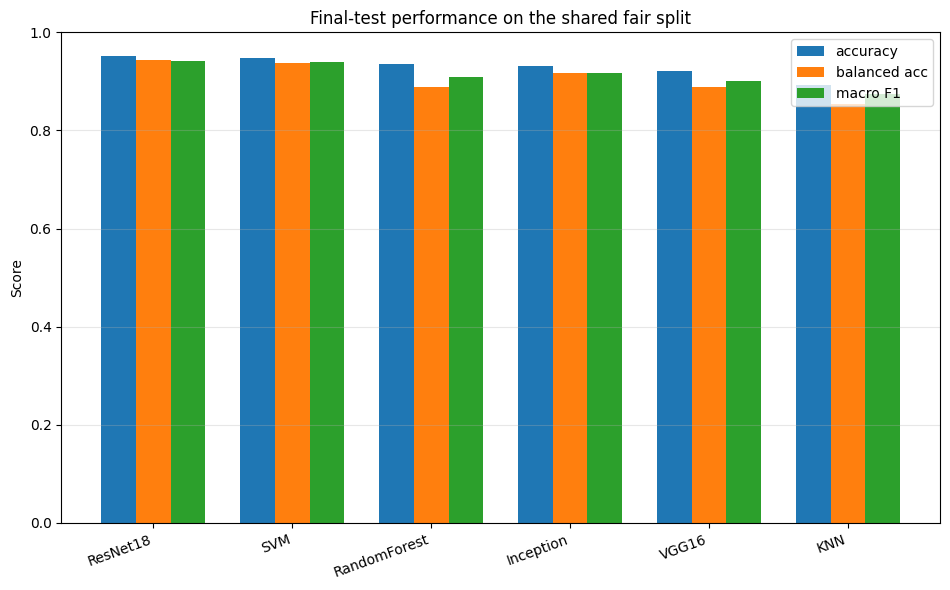

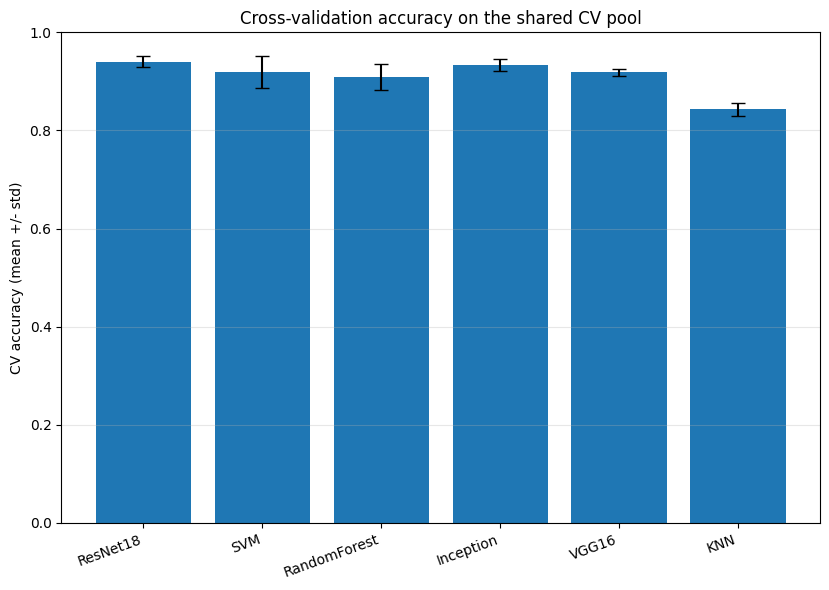


Comparison saved to: /content/model_comparison_shared_fair


In [14]:
# ============================================================
# COMPARE ALL MODELS ON THE EXACT SAME FINAL TEST SET
#
# Reads only already-saved files, so it does NOT retrain anything.
#
# Final-test metrics (accuracy / balanced accuracy / macro F1):
#   - classical (KNN, RF, SVM): from the saved KNN/RF/SVM summary CSV
#   - deep nets (ResNet18, VGG16, Inception): recomputed from each model's
#     saved final-test confusion matrix, so all six report the same metrics.
#
# Cross-validation accuracy (mean +/- std) is also collected, because with
# only ~231 test cells the single test number is noisy; the CV spread tells
# you whether the top models are really separable or within noise.
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CLASSICAL_DIR = "/content/thesis_results_KNN_RF_shared_fair_split"
DL_DIRS = {
    "ResNet18":  "/content/cross_val_results_Resnet18_shared_fair",
    "VGG16":     "/content/cross_val_results_VGG16_shared_fair",
    "Inception": "/content/cross_val_results_Inception_shared_fair",
}
COMPARE_DIR = "/content/model_comparison_shared_fair"
os.makedirs(COMPARE_DIR, exist_ok=True)


def metrics_from_cm(cm):
    """accuracy, balanced accuracy (mean recall), macro F1 from a confusion matrix."""
    cm = np.asarray(cm, dtype=float)
    total = cm.sum()
    acc = np.trace(cm) / total if total > 0 else 0.0
    recalls, f1s = [], []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        recalls.append(rec)
        f1s.append(f1)
    return acc, float(np.mean(recalls)), float(np.mean(f1s))


rows = []

# ------------------------------------------------------------
# Classical models (KNN, Random Forest, SVM)
# ------------------------------------------------------------
classical_test_csv = os.path.join(CLASSICAL_DIR, "KNN_RF_shared_FINAL_TEST_summary.csv")
classical_cv_csv   = os.path.join(CLASSICAL_DIR, "KNN_RF_shared_CV_summary.csv")

cv_lookup = {}
if os.path.exists(classical_cv_csv):
    cvdf = pd.read_csv(classical_cv_csv)
    for _, r in cvdf.iterrows():
        cv_lookup[r["model"]] = (float(r["cv_mean_accuracy"]),
                                 float(r["cv_std_accuracy"]))

if os.path.exists(classical_test_csv):
    cdf = pd.read_csv(classical_test_csv)
    for _, r in cdf.iterrows():
        cvm, cvs = cv_lookup.get(r["model"], (np.nan, np.nan))
        rows.append({
            "model": r["model"],
            "modality": "Predefined ephys features",
            "test_accuracy": float(r["accuracy"]),
            "test_balanced_accuracy": float(r["balanced_accuracy"]),
            "test_macro_f1": float(r["macro_f1"]),
            "cv_mean_accuracy": cvm,
            "cv_std_accuracy": cvs,
        })
else:
    print("WARNING: classical summary not found:", classical_test_csv)

# ------------------------------------------------------------
# Deep-learning models (ResNet18, VGG16, Inception)
# ------------------------------------------------------------
for name, d in DL_DIRS.items():
    cm_csv = os.path.join(d, "final_test_confusion_matrix.csv")
    if not os.path.exists(cm_csv):
        print(f"WARNING: confusion matrix not found for {name}: {cm_csv}")
        continue

    cm = pd.read_csv(cm_csv, index_col=0).values
    acc, bal, mf1 = metrics_from_cm(cm)

    cvm, cvs = np.nan, np.nan
    metrics_json = os.path.join(d, "final_metrics.json")
    if os.path.exists(metrics_json):
        with open(metrics_json) as f:
            m = json.load(f)
        cvm = float(m.get("cv_mean_best_val_acc", np.nan))
        cvs = float(m.get("cv_std_best_val_acc", np.nan))

    rows.append({
        "model": name,
        "modality": "WST S1 (deep learning)",
        "test_accuracy": acc,
        "test_balanced_accuracy": bal,
        "test_macro_f1": mf1,
        "cv_mean_accuracy": cvm,
        "cv_std_accuracy": cvs,
    })

comparison = (
    pd.DataFrame(rows)
    .sort_values("test_accuracy", ascending=False)
    .reset_index(drop=True)
)

print("\n==============================")
print("FINAL TEST COMPARISON (same test cells for every model)")
print("==============================")
print(comparison.round(4).to_string(index=False))

comparison.to_csv(os.path.join(COMPARE_DIR, "model_comparison.csv"), index=False)

# ------------------------------------------------------------
# Plot 1: final-test metrics (grouped bars)
# ------------------------------------------------------------
if len(comparison) > 0:
    metrics = ["test_accuracy", "test_balanced_accuracy", "test_macro_f1"]
    labels  = ["accuracy", "balanced acc", "macro F1"]
    x = np.arange(len(comparison))
    width = 0.25

    plt.figure(figsize=(max(8, 1.6 * len(comparison)), 6))
    for i, (m, lab) in enumerate(zip(metrics, labels)):
        plt.bar(x + (i - 1) * width, comparison[m].values, width, label=lab)

    plt.xticks(x, comparison["model"].values, rotation=20, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title("Final-test performance on the shared fair split")
    plt.legend()
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(COMPARE_DIR, "model_comparison.png"), dpi=300)
    plt.show()

# ------------------------------------------------------------
# Plot 2: CV accuracy with error bars (shows if top models overlap)
# ------------------------------------------------------------
cv_plot = comparison.dropna(subset=["cv_mean_accuracy"]).reset_index(drop=True)
if len(cv_plot) > 0:
    x = np.arange(len(cv_plot))
    plt.figure(figsize=(max(8, 1.4 * len(cv_plot)), 6))
    plt.bar(x, cv_plot["cv_mean_accuracy"].values,
            yerr=cv_plot["cv_std_accuracy"].fillna(0).values,
            capsize=5)
    plt.xticks(x, cv_plot["model"].values, rotation=20, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("CV accuracy (mean +/- std)")
    plt.title("Cross-validation accuracy on the shared CV pool")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(COMPARE_DIR, "model_comparison_cv.png"), dpi=300)
    plt.show()

print("\nComparison saved to:", COMPARE_DIR)

## Step 7 — (Optional) Save results to Google Drive

In [ ]:
# ============================================================
# (Optional) Zip every results folder and copy it to Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil

folders = [
    "/content/shared_fair_splits",
    "/content/thesis_results_KNN_RF_shared_fair_split",
    "/content/cross_val_results_Resnet18_shared_fair",
    "/content/cross_val_results_VGG16_shared_fair",
    "/content/cross_val_results_Inception_shared_fair",
    "/content/model_comparison_shared_fair",
]

DRIVE_DEST = "/content/drive/MyDrive/WST_Model_Results"
os.makedirs(DRIVE_DEST, exist_ok=True)

for folder in folders:
    if not os.path.exists(folder):
        print("Folder not found, skipping:", folder)
        continue

    folder_name = os.path.basename(folder)
    print("\nZipping", folder_name, "...")
    shutil.make_archive(folder, "zip", folder)

    print("Copying", folder_name + ".zip", "to Drive ...")
    shutil.copy(folder + ".zip", DRIVE_DEST)
    print("Done:", folder_name + ".zip")

print("\nAll available folders uploaded to:", DRIVE_DEST)
